#Time - Significance

Time - Normality Test

In [ ]:
import pandas as pd
import numpy as np
import re
from scipy.stats import shapiro

# -----------------------------
# Helper: convert duration text to seconds
# -----------------------------
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower().strip()

    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)

    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0

    # If no min/sec text, try numeric
    if mins is None and secs is None:
        try:
            return float(s)
        except:
            return np.nan

    return minutes * 60 + seconds


# -----------------------------
# Load both time files
# -----------------------------
parsons = pd.read_excel("Parsons Problem time.xlsx")
openended = pd.read_excel("Traditional Programming time.xlsx")

# Convert Duration to seconds
parsons["time_sec"] = parsons["Duration"].apply(duration_to_seconds)
openended["time_sec"] = openended["Duration"].apply(duration_to_seconds)

# -----------------------------
# Merge by Participant ID
# -----------------------------
merged = pd.merge(
    parsons[["Participant ID", "time_sec"]],
    openended[["Participant ID", "time_sec"]],
    on="Participant ID",
    suffixes=("_parsons", "_open")
)

# -----------------------------
# Compute paired difference (open - parsons)
# -----------------------------
merged["time_diff_sec"] = merged["time_sec_open"] - merged["time_sec_parsons"]

time_diff = merged["time_diff_sec"].dropna()

print("N (paired participants):", len(time_diff))

# -----------------------------
# Shapiro–Wilk normality test on differences
# -----------------------------
if len(time_diff) < 3:
    print("Not enough data for Shapiro–Wilk test (need ≥ 3).")
elif np.isclose(time_diff.var(ddof=1), 0.0):
    print("Zero variance in time differences — normality test not meaningful.")
else:
    w, p = shapiro(time_diff)
    print(f"W-statistic: {w:.6f}")
    print(f"p-value: {p:.6g}")
    print("Differences normally distributed (p ≥ 0.05)?",
          "Yes" if p >= 0.05 else "No")



N (paired participants): 34
W-statistic: 0.929810
p-value: 0.0308866
Differences normally distributed (p ≥ 0.05)? No


Time Difference - Histogram

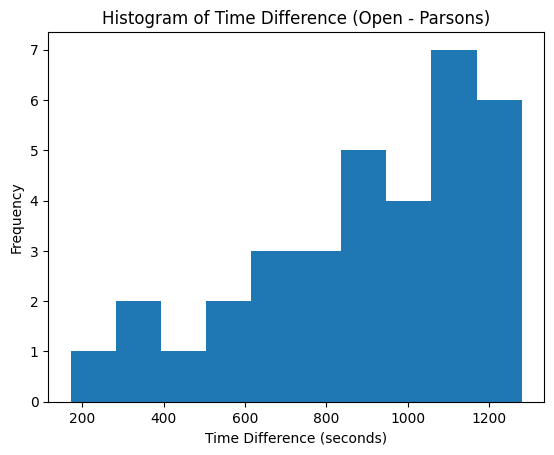

In [ ]:
# Histogram for Time Difference (Open-ended - Parsons)
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: convert duration text to seconds
# -----------------------------
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)

    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0

    if mins is None and secs is None:
        try:
            return float(s)
        except:
            return np.nan

    return minutes * 60 + seconds

# -----------------------------
# Load time files
# -----------------------------
parsons = pd.read_excel("Parsons Problem time.xlsx")
openended = pd.read_excel("Traditional Programming time.xlsx")

# Convert Duration to seconds
parsons["time_sec"] = parsons["Duration"].apply(duration_to_seconds)
openended["time_sec"] = openended["Duration"].apply(duration_to_seconds)

# -----------------------------
# Merge by Participant ID
# -----------------------------
merged = pd.merge(
    parsons[["Participant ID", "time_sec"]],
    openended[["Participant ID", "time_sec"]],
    on="Participant ID",
    suffixes=("_parsons", "_open")
)

# -----------------------------
# Compute time difference (Open - Parsons)
# -----------------------------
merged["Time_Difference_sec"] = (
    merged["time_sec_open"] - merged["time_sec_parsons"]
)

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure()
plt.hist(merged["Time_Difference_sec"].dropna(), bins=10)
plt.title("Histogram of Time Difference (Open - Parsons)")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()


Time Wilcoxon test

In [ ]:
# Recommended Wilcoxon Signed-Rank Test Code
# Includes W statistic, p-value, Z value, and effect size (r)

import pandas as pd
import numpy as np
import re
from scipy.stats import wilcoxon

# ---------- Helper: convert duration text to seconds ----------
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)
    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0
    return minutes * 60 + seconds

# ---------- Load datasets ----------
parsons = pd.read_excel("Parsons Problem time.xlsx")
traditional = pd.read_excel("Traditional Programming time.xlsx")

# Convert to seconds
parsons["sec"] = parsons["Duration"].apply(duration_to_seconds)
traditional["sec"] = traditional["Duration"].apply(duration_to_seconds)

# Merge paired data
merged = pd.merge(
    parsons[["Participant ID", "sec"]],
    traditional[["Participant ID", "sec"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# Compute difference (Traditional - Parsons)
diff = merged["sec_traditional"] - merged["sec_parsons"]

# Remove zero differences (Wilcoxon requirement)
diff_nonzero = diff[diff != 0]

# ---------- Wilcoxon test ----------
W_stat, p_value = wilcoxon(diff_nonzero)

# ---------- Compute Z manually ----------
n = len(diff_nonzero)
mean_W = n * (n + 1) / 4
std_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

Z = (W_stat - mean_W) / std_W

# ---------- Effect size (r) ----------
r = Z / np.sqrt(n)

# ---------- Print results ----------
print("Paired N:", n)
print("Wilcoxon W:", W_stat)
print("p-value:", p_value)
print("Z value:", Z)
print("Effect size r:", r)


Paired N: 34
Wilcoxon W: 0.0
p-value: 1.1641532182693481e-10
Z value: -5.086213249303582
Effect size r: -0.8722783759886469


# Score - Significance

Score - Normality Test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

# ---------------------------------
# 1) Load both score files
# ---------------------------------
parsons = pd.read_excel("Parsons Problem scores.xlsx")
openended = pd.read_excel("Traditional Programming scores.xlsx")

# Inspect columns (optional)
print("Parsons columns:", parsons.columns.tolist())
print("Open-ended columns:", openended.columns.tolist())

# ---------------------------------
# 2) Merge by Participant ID
# ---------------------------------
merged = pd.merge(
    parsons[["Participant ID", "Total Score"]],
    openended[["Participant ID", "Total Score"]],
    on="Participant ID",
    suffixes=("_parsons", "_open")
)

# ---------------------------------
# 3) Compute score difference
#    (Open-ended − Parsons)
# ---------------------------------
merged["score_diff"] = merged["Total Score_open"] - merged["Total Score_parsons"]

score_diff = merged["score_diff"].dropna()

print("\nNumber of paired participants:", len(score_diff))

# ---------------------------------
# 4) Shapiro–Wilk normality test
#    (on differences — CORRECT)
# ---------------------------------
if len(score_diff) < 3:
    print("Not enough data for Shapiro–Wilk test (need ≥ 3).")
elif np.isclose(score_diff.var(ddof=1), 0.0):
    print("Zero variance in score differences — normality not meaningful.")
else:
    w, p = shapiro(score_diff)

    print(f"W-statistic: {w:.6f}")
    print(f"p-value: {p:.6g}")
    print("Differences normally distributed (p ≥ 0.05)?",
          "Yes" if p >= 0.05 else "No")


Parsons columns: ['Participant ID', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Question 6', 'Question 7', 'Question 8', 'Question 9', 'Question 10', 'Question 11', 'Question 12', 'Question 13', 'Question 14', 'Question 15', 'Question 16', 'Total Score']
Open-ended columns: ['Participant ID', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Question 6', 'Question 7', 'Question 8', 'Question 9', 'Question 10', 'Question 11', 'Question 12', 'Question 13', 'Question 14', 'Question 15', 'Question 16', 'Total Score']

Number of paired participants: 34
W-statistic: 0.930094
p-value: 0.0314787
Differences normally distributed (p ≥ 0.05)? No


Score Normality - Histogram

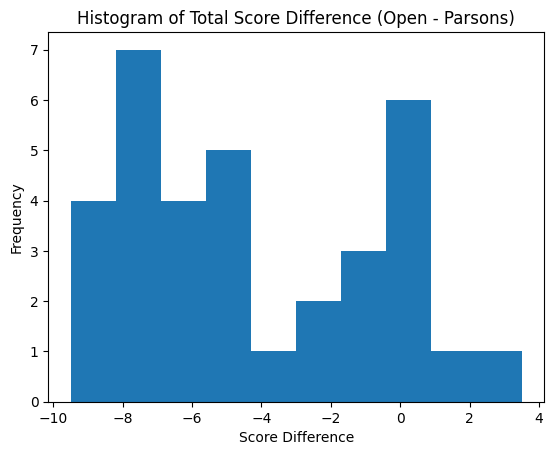

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# 1) Load score files
# ----------------------------------
parsons = pd.read_excel("Parsons Problem scores.xlsx")
openended = pd.read_excel("Traditional Programming scores.xlsx")

# ----------------------------------
# 2) Merge by Participant ID
# ----------------------------------
merged = pd.merge(
    parsons[["Participant ID", "Total Score"]],
    openended[["Participant ID", "Total Score"]],
    on="Participant ID",
    suffixes=("_parsons", "_open")
)

# ----------------------------------
# 3) Compute score difference
#    (Open-ended - Parsons)
# ----------------------------------
merged["Score_Difference"] = (
    merged["Total Score_open"] - merged["Total Score_parsons"]
)

# ----------------------------------
# 4) Plot histogram of score difference
# ----------------------------------
plt.figure()
plt.hist(merged["Score_Difference"].dropna(), bins=10)
plt.title("Histogram of Total Score Difference (Open - Parsons)")
plt.xlabel("Score Difference")
plt.ylabel("Frequency")
plt.show()




Score Wilcoxon test

In [ ]:
# Wilcoxon Signed-Rank Test for Total Scores (Parsons vs Traditional)
# Includes W, p-value, Z value, and effect size (r)

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Load datasets
parsons = pd.read_excel("Parsons Problem scores.xlsx")
traditional = pd.read_excel("Traditional Programming scores.xlsx")

# Merge paired data
merged = pd.merge(
    parsons[["Participant ID", "Total Score"]],
    traditional[["Participant ID", "Total Score"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# Compute difference (Traditional - Parsons)
diff = merged["Total Score_traditional"] - merged["Total Score_parsons"]

# Remove zero differences
diff_nonzero = diff[diff != 0]

# Wilcoxon test
W_stat, p_value = wilcoxon(diff_nonzero)

# Compute Z manually
n = len(diff_nonzero)
mean_W = n * (n + 1) / 4
std_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

Z = (W_stat - mean_W) / std_W

# Effect size
r = Z / np.sqrt(n)

# ---------- Print results ----------
print("Paired N:", n)
print("Wilcoxon W:", W_stat)
print("p-value:", p_value)
print("Z value:", Z)
print("Effect size r:", r)



Paired N: 31
Wilcoxon W: 22.5
p-value: 9.822812819702331e-06
Z value: -4.419020906912485
Effect size r: -0.7936795846486497


Correctness Score - Normality Test

In [ ]:
# Test Normality of Correctness Score (Parsons vs Traditional)

import pandas as pd
import numpy as np
from scipy.stats import shapiro

# Load files
traditional = pd.read_excel("Traditional Programming scores with error rates.xlsx")
parsons = pd.read_excel("Parsons Problem scores with error rates.xlsx")

# Compute Correctness Score (Correct / Attempted)
traditional["Correctness"] = traditional["Total Score"] / traditional["Attempted"]
parsons["Correctness"] = parsons["Total Score"] / parsons["Attempted"]

# Merge paired data
merged = pd.merge(
    parsons[["Participant ID", "Correctness"]],
    traditional[["Participant ID", "Correctness"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# ---- Normality Tests ----

# 1. Parsons correctness
w_parsons, p_parsons = shapiro(merged["Correctness_parsons"])

# 2. Traditional correctness
w_traditional, p_traditional = shapiro(merged["Correctness_traditional"])

# 3. Difference in correctness
merged["diff"] = merged["Correctness_traditional"] - merged["Correctness_parsons"]
w_diff, p_diff = shapiro(merged["diff"])

results = pd.DataFrame({
    "Shapiro W": [w_parsons, w_traditional, w_diff],
    "p-value": [p_parsons, p_traditional, p_diff]
}, index=["Parsons Correctness",
          "Traditional Correctness",
          "Difference (Trad - Parsons)"])

results

,Shapiro W,p-value
Parsons Correctness,0.868127,7.313232e-04
Traditional Correctness,0.490887,1.006340e-09
Difference (Trad - Parsons),0.809060,3.855034e-05


Correctness score - Significance

In [ ]:
# Wilcoxon Signed-Rank Test for Correctness (Parsons vs Traditional)
# Includes W, p-value, Z value, and effect size (r)

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Load files
traditional = pd.read_excel("Traditional Programming scores with error rates.xlsx")
parsons = pd.read_excel("Parsons Problem scores with error rates.xlsx")

# Compute correctness
traditional["Correctness"] = traditional["Total Score"] / traditional["Attempted"]
parsons["Correctness"] = parsons["Total Score"] / parsons["Attempted"]

# Merge paired data
merged = pd.merge(
    parsons[["Participant ID", "Correctness"]],
    traditional[["Participant ID", "Correctness"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# Difference (Traditional - Parsons)
diff = merged["Correctness_traditional"] - merged["Correctness_parsons"]

# Remove zero differences
diff_nonzero = diff[diff != 0]

# Wilcoxon test
W_stat, p_value = wilcoxon(diff_nonzero)

# Compute Z manually
n = len(diff_nonzero)
mean_W = n * (n + 1) / 4
std_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

Z = (W_stat - mean_W) / std_W

# Effect size
r = Z / np.sqrt(n)

results = {
    "Paired N (nonzero diffs)": n,
    "Wilcoxon W": W_stat,
    "p-value": p_value,
    "Z value": Z,
    "Effect size r": r
}

pd.DataFrame(results, index=["Correctness Comparison"])

,Paired N (nonzero diffs),Wilcoxon W,p-value,Z value,Effect size r
Correctness Comparison,26,88.0,0.02599,-2.222323,-0.435833


# Time - PP and TP

Parsons Problem Time Statistics

In [ ]:
import pandas as pd
import numpy as np
import re

def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)
    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0
    return minutes * 60 + seconds

df = pd.read_excel("Parsons Problem time.xlsx")

df["Duration_seconds"] = df["Duration"].apply(duration_to_seconds)

time = df["Duration_seconds"].dropna()

desc = {
    "N": time.count(),
    "Mean (sec)": time.mean(),
    "SD (sec)": time.std(ddof=1),
    "Median (sec)": time.median(),
    "Q1 (sec)": time.quantile(0.25),
    "Q3 (sec)": time.quantile(0.75),
    "IQR (sec)": time.quantile(0.75) - time.quantile(0.25),
    "Min (sec)": time.min(),
    "Max (sec)": time.max()
}

pd.DataFrame(desc, index=["Parsons Problem Time"])


,N,Mean (sec),SD (sec),Median (sec),Q1 (sec),Q3 (sec),IQR (sec),Min (sec),Max (sec)
Parsons Problem Time,34,882.147059,320.216606,799.5,646.5,1043.75,397.25,288,1801


Parsons Problem Time - Histogram

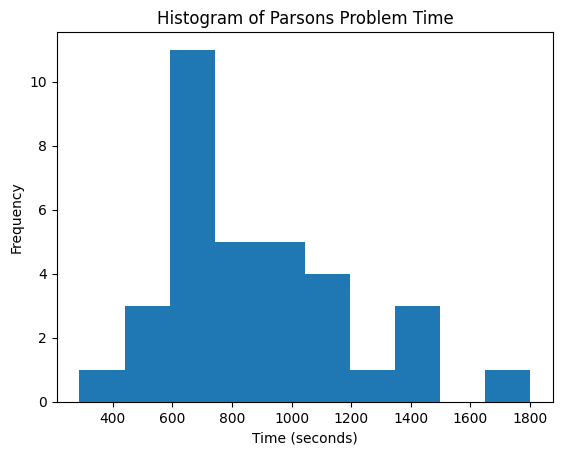

In [ ]:
# Histogram for Parsons Problem Time (Duration)
# Uses matplotlib only, single plot, no explicit colors

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: convert duration text to seconds
# -----------------------------
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)

    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0

    if mins is None and secs is None:
        try:
            return float(s)
        except:
            return np.nan

    return minutes * 60 + seconds

# -----------------------------
# Load Parsons Problem time file
# -----------------------------
df = pd.read_excel("Parsons Problem time.xlsx")

# Convert Duration to seconds
df["Duration_seconds"] = df["Duration"].apply(duration_to_seconds)

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure()
plt.hist(df["Duration_seconds"].dropna(), bins=10)
plt.title("Histogram of Parsons Problem Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()


Traditional Programming Time - Statistics

In [ ]:
import pandas as pd
import numpy as np
import re

def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)
    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0
    return minutes * 60 + seconds

df = pd.read_excel("Traditional Programming time.xlsx")

df["Duration_seconds"] = df["Duration"].apply(duration_to_seconds)

time = df["Duration_seconds"].dropna()

desc = {
    "N": time.count(),
    "Mean (sec)": time.mean(),
    "SD (sec)": time.std(ddof=1),
    "Median (sec)": time.median(),
    "Q1 (sec)": time.quantile(0.25),
    "Q3 (sec)": time.quantile(0.75),
    "IQR (sec)": time.quantile(0.75) - time.quantile(0.25),
    "Min (sec)": time.min(),
    "Max (sec)": time.max()
}

pd.DataFrame(desc, index=["Traditional Programming Time"])


,N,Mean (sec),SD (sec),Median (sec),Q1 (sec),Q3 (sec),IQR (sec),Min (sec),Max (sec)
Traditional Programming Time,34,1777.088235,108.156836,1800.0,1799.25,1801.0,1.75,1449,1973


Traditional Programming Time - Histogram

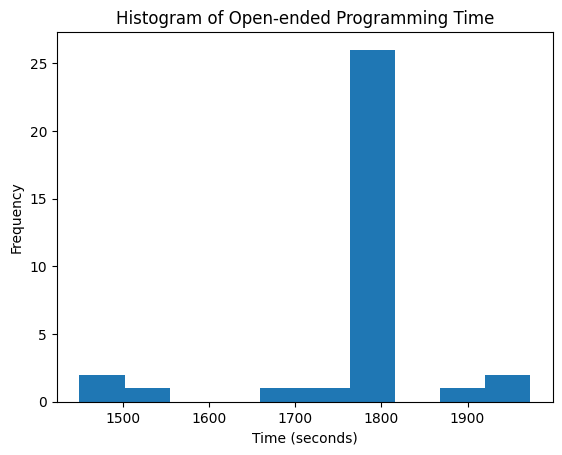

In [ ]:
# Histogram for Traditional (Open-ended) Programming Time
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: convert duration text to seconds
# -----------------------------
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower().strip()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)

    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0

    if mins is None and secs is None:
        try:
            return float(s)
        except:
            return np.nan

    return minutes * 60 + seconds

# -----------------------------
# Load Traditional Programming time file
# -----------------------------
df = pd.read_excel("Traditional Programming time.xlsx")

# Convert Duration to seconds
df["Duration_seconds"] = df["Duration"].apply(duration_to_seconds)

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure()
plt.hist(df["Duration_seconds"].dropna(), bins=10)
plt.title("Histogram of Open-ended Programming Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()


Time - Boxplot

/tmp/ipykernel_595/3946798376.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


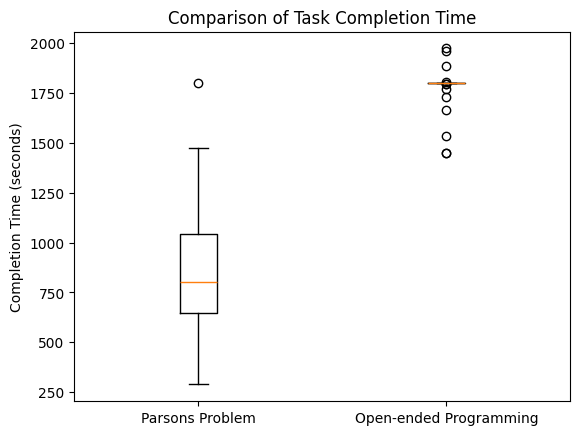

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def duration_to_seconds(x):
    s = str(x).lower()
    mins = re.search(r'(\d+)\s*min', s)
    secs = re.search(r'(\d+)\s*sec', s)
    minutes = int(mins.group(1)) if mins else 0
    seconds = int(secs.group(1)) if secs else 0
    return minutes * 60 + seconds

# Load data
parsons = pd.read_excel("Parsons Problem time.xlsx")
traditional = pd.read_excel("Traditional Programming time.xlsx")

# Convert time to seconds
parsons["Time"] = parsons["Duration"].apply(duration_to_seconds)
traditional["Time"] = traditional["Duration"].apply(duration_to_seconds)

data = [parsons["Time"], traditional["Time"]]
labels = ["Parsons Problem", "Open-ended Programming"]

plt.figure()
plt.boxplot(data, labels=labels)
plt.ylabel("Completion Time (seconds)")
plt.title("Comparison of Task Completion Time")
plt.show()

# Score - PP and TP

Parsons Problem Score Statistics

In [ ]:
import pandas as pd

# Load Parsons Problem scores file
df = pd.read_excel("Parsons Problem scores.xlsx")

# Select Total Score
scores = df["Total Score"].dropna()

# Descriptive statistics
desc = {
    "N": scores.count(),
    "Mean": scores.mean(),
    "SD": scores.std(ddof=1),
    "Median": scores.median(),
    "Q1": scores.quantile(0.25),
    "Q3": scores.quantile(0.75),
    "IQR": scores.quantile(0.75) - scores.quantile(0.25),
    "Min": scores.min(),
    "Max": scores.max()
}

pd.DataFrame(desc, index=["Parsons Problem Score"])


,N,Mean,SD,Median,Q1,Q3,IQR,Min,Max
Parsons Problem Score,34,13.955882,1.017779,14.25,13.5,14.5,1.0,11.0,15.0


Parsons Problem Score - Histogram

Columns: ['Participant ID', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Question 6', 'Question 7', 'Question 8', 'Question 9', 'Question 10', 'Question 11', 'Question 12', 'Question 13', 'Question 14', 'Question 15', 'Question 16', 'Total Score']


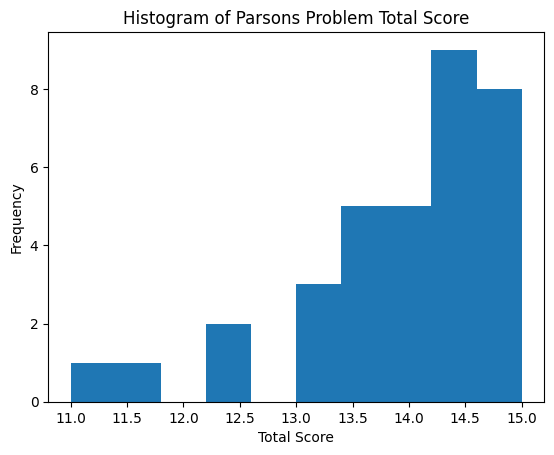

In [ ]:
# Histogram for Parsons Problem Total Score
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Parsons Problem scores file
# -----------------------------
df = pd.read_excel("Parsons Problem scores.xlsx")

# Inspect columns (optional)
print("Columns:", df.columns.tolist())

# -----------------------------
# Plot histogram for Total Score
# -----------------------------
plt.figure()
plt.hist(df["Total Score"].dropna(), bins=10)
plt.title("Histogram of Parsons Problem Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()


Parsons Problem Correctness Score

In [ ]:
# CODE 1: Compute individual correctness percentage for Parsons Problem
import pandas as pd
import numpy as np

# Load Parsons Problem scores
df = pd.read_excel("Parsons Problem scores.xlsx")

# Since all attempted = 15
ATTEMPTED = 15

# Compute correctness percentage
df["Correctness_Percentage"] = (df["Total Score"] / ATTEMPTED) * 100

# Show per-student correctness
df[["Participant ID", "Total Score", "Correctness_Percentage"]]


,Participant ID,Total Score,Correctness_Percentage
0,P1,14.0,93.333333
1,P10,13.5,90.000000
2,P11,15.0,100.000000
3,P12,15.0,100.000000
4,P13,14.0,93.333333
5,P14,15.0,100.000000
6,P15,13.5,90.000000
7,P16,14.5,96.666667
8,P17,14.5,96.666667
9,P18,11.5,76.666667


Parsons Problem Correctness Score Statistics

In [ ]:
# CODE 2: Descriptive statistics for Parsons Problem correctness percentage
import pandas as pd
import numpy as np

# Load data
df = pd.read_excel("Parsons Problem scores.xlsx")

ATTEMPTED = 15
df["Correctness_Percentage"] = (df["Total Score"] / ATTEMPTED) * 100

correct = df["Correctness_Percentage"].dropna()

desc = {
    "N": correct.count(),
    "Mean (%)": correct.mean(),
    "SD (%)": correct.std(ddof=1),
    "Median (%)": correct.median(),
    "Q1 (%)": correct.quantile(0.25),
    "Q3 (%)": correct.quantile(0.75),
    "IQR (%)": correct.quantile(0.75) - correct.quantile(0.25),
    "Min (%)": correct.min(),
    "Max (%)": correct.max()
}

pd.DataFrame(desc, index=["Parsons Problem Correctness %"])


,N,Mean (%),SD (%),Median (%),Q1 (%),Q3 (%),IQR (%),Min (%),Max (%)
Parsons Problem Correctness %,34,93.039216,6.785191,95.0,90.0,96.666667,6.666667,73.333333,100.0


Parsons Problem Correctness Score Histogram

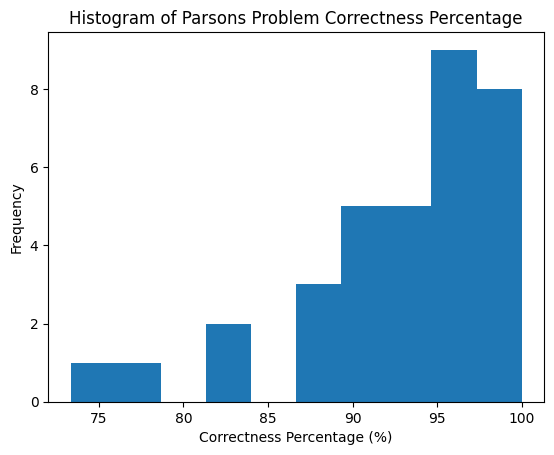

In [ ]:
# CODE 3: Histogram for Parsons Problem correctness percentage
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Parsons Problem scores.xlsx")

ATTEMPTED = 15
df["Correctness_Percentage"] = (df["Total Score"] / ATTEMPTED) * 100

# Plot histogram
plt.figure()
plt.hist(df["Correctness_Percentage"].dropna(), bins=10)
plt.title("Histogram of Parsons Problem Correctness Percentage")
plt.xlabel("Correctness Percentage (%)")
plt.ylabel("Frequency")
plt.show()


Traditional Programming Scores Statistics

In [ ]:
import pandas as pd

df = pd.read_excel("Traditional Programming scores.xlsx")

# Select Total Score
scores = df["Total Score"].dropna()

# Descriptive statistics
desc = {
    "N": scores.count(),
    "Mean": scores.mean(),
    "SD": scores.std(ddof=1),
    "Median": scores.median(),
    "Q1": scores.quantile(0.25),
    "Q3": scores.quantile(0.75),
    "IQR": scores.quantile(0.75) - scores.quantile(0.25),
    "Min": scores.min(),
    "Max": scores.max()
}

pd.DataFrame(desc, index=["Traditional Programming Score"])


,N,Mean,SD,Median,Q1,Q3,IQR,Min,Max
Parsons Problem Score,34,9.705882,3.481809,8.75,7.0,13.375,6.375,3.5,15.0


Traditional Programming Scores - Histogram

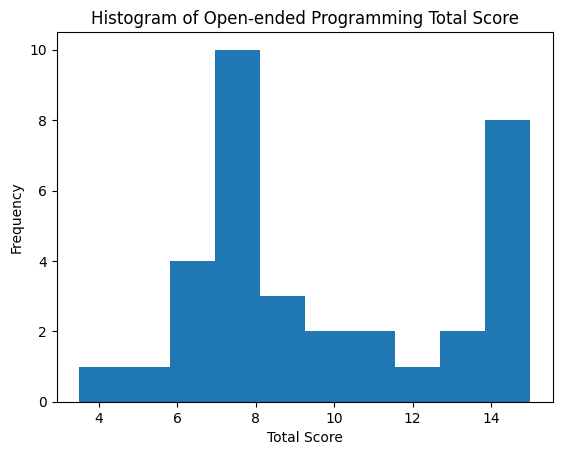

In [ ]:
# Histogram for Traditional (Open-ended) Programming Total Score
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Traditional Programming scores file
# -----------------------------
df = pd.read_excel("Traditional Programming scores.xlsx")

# -----------------------------
# Plot histogram for Total Score
# -----------------------------
plt.figure()
plt.hist(df["Total Score"].dropna(), bins=10)
plt.title("Histogram of Open-ended Programming Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()


Traditional Programming Correctness Score

In [ ]:
import pandas as pd
import numpy as np

# Load your file
df = pd.read_excel("Traditional Programming scores with error rates.xlsx")

# Inspect columns (optional)
print(df.columns.tolist())

# Assumptions:
# - 'Attempted' = number of questions attempted
# - 'Total Score' = number of correct answers
# Change column names below ONLY if yours differ

df["Correctness_Percentage"] = np.where(
    df["Attempted"] > 0,
    (df["Total Score"] / df["Attempted"]) * 100,
    np.nan
)

# View per-student correctness
df[["Participant ID", "Attempted", "Total Score", "Correctness_Percentage"]]


['Participant ID', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Question 6', 'Question 7', 'Question 8', 'Question 9', 'Question 10', 'Question 11', 'Question 12', 'Question 13', 'Question 14', 'Question 15', 'Question 16', 'Total Score', 'Attempted']


,Participant ID,Attempted,Total Score,Correctness_Percentage
0,P1,14,14.0,100.000000
1,P10,8,7.5,93.750000
2,P11,7,7.0,100.000000
3,P12,6,6.0,100.000000
4,P13,15,14.5,96.666667
5,P14,8,8.0,100.000000
6,P15,8,7.0,87.500000
7,P16,10,9.5,95.000000
8,P17,15,15.0,100.000000
9,P18,6,5.5,91.666667


Traditional Programming Correctness Score Statistics

In [ ]:
correct = df["Correctness_Percentage"].dropna()

desc = {
    "N": correct.count(),
    "Mean (%)": correct.mean(),
    "SD (%)": correct.std(ddof=1),
    "Median (%)": correct.median(),
    "Q1 (%)": correct.quantile(0.25),
    "Q3 (%)": correct.quantile(0.75),
    "IQR (%)": correct.quantile(0.75) - correct.quantile(0.25),
    "Min (%)": correct.min(),
    "Max (%)": correct.max()
}

pd.DataFrame(desc, index=["Correctness Percentage"])


,N,Mean (%),SD (%),Median (%),Q1 (%),Q3 (%),IQR (%),Min (%),Max (%)
Correctness Percentage,34,95.240609,11.158189,100.0,95.357143,100.0,4.642857,43.75,100.0


Traditional Programming Correctness Score Histogram

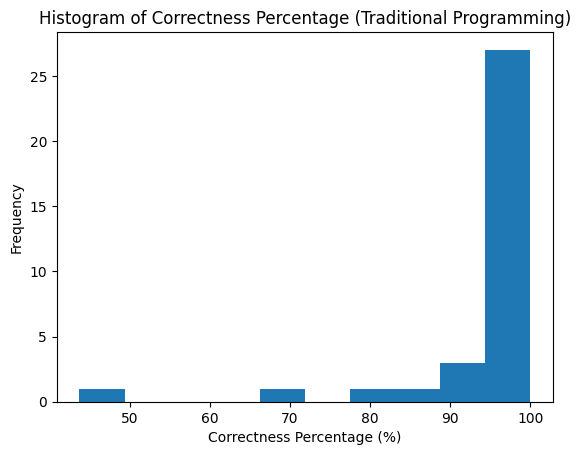

In [ ]:
# Histogram for Correctness Percentage (Traditional Programming)
# Single plot, matplotlib only, no explicit colors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the file
df = pd.read_excel("Traditional Programming scores with error rates.xlsx")

# Compute correctness percentage if not already present
if "Correctness_Percentage" not in df.columns:
    df["Correctness_Percentage"] = np.where(
        df["Attempted"] > 0,
        (df["Total Score"] / df["Attempted"]) * 100,
        np.nan
    )

# Plot histogram
plt.figure()
plt.hist(df["Correctness_Percentage"].dropna(), bins=10)
plt.title("Histogram of Correctness Percentage (Traditional Programming)")
plt.xlabel("Correctness Percentage (%)")
plt.ylabel("Frequency")
plt.show()


Correctness Score Boxplot

/tmp/ipykernel_595/673825819.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


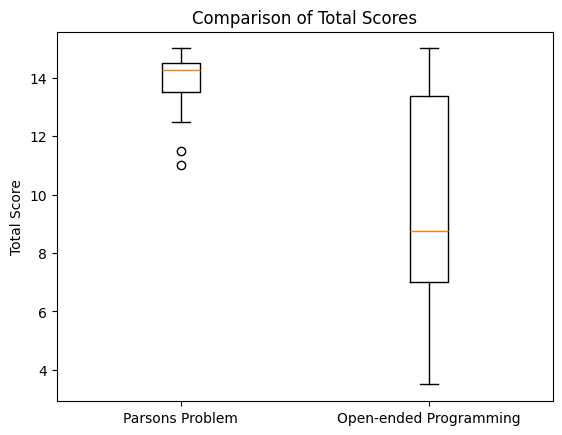

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
parsons = pd.read_excel("Parsons Problem scores.xlsx")
traditional = pd.read_excel("Traditional Programming scores.xlsx")

# Prepare data
data = [
    parsons["Total Score"],
    traditional["Total Score"]
]

labels = ["Parsons Problem", "Open-ended Programming"]

# Plot
plt.figure()
plt.boxplot(data, labels=labels)
plt.ylabel("Total Score")
plt.title("Comparison of Total Scores")
plt.show()

Correctness Score Percentage - Boxplot

/tmp/ipykernel_595/2303500319.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


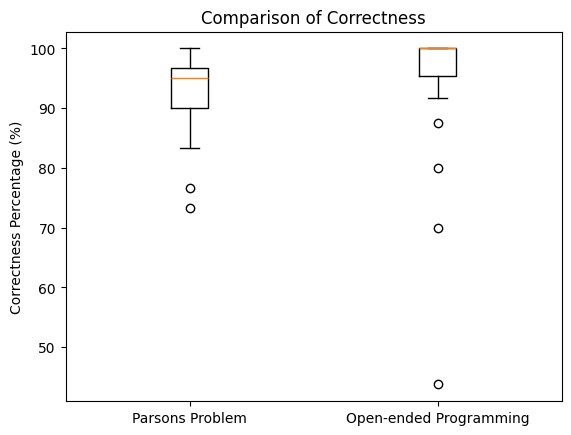

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load files
parsons = pd.read_excel("Parsons Problem scores with error rates.xlsx")
traditional = pd.read_excel("Traditional Programming scores with error rates.xlsx")

# Compute correctness percentage
parsons["Correctness %"] = (parsons["Total Score"] / parsons["Attempted"]) * 100
traditional["Correctness %"] = (traditional["Total Score"] / traditional["Attempted"]) * 100

# Prepare data
data = [
    parsons["Correctness %"],
    traditional["Correctness %"]
]

labels = ["Parsons Problem", "Open-ended Programming"]

# Plot
plt.figure()
plt.boxplot(data, labels=labels)
plt.ylabel("Correctness Percentage (%)")
plt.title("Comparison of Correctness")
plt.show()

# UMUX - PP and TP

Parson Problem UMUX Likert Values

Descriptive statistics (Likert items)
              N   Mean     SD  Median   Q1   Q3  Min  Max
UMUX-Lite_1  34  4.147  0.989     4.0  4.0  5.0    1    5
UMUX-Lite_2  34  4.500  0.788     5.0  4.0  5.0    1    5

Likert frequency table (counts)
 Likert  UMUX-Lite_1_count  UMUX-Lite_2_count
      1                  1                  1
      2                  2                  0
      3                  2                  0
      4                 15                 13
      5                 14                 20


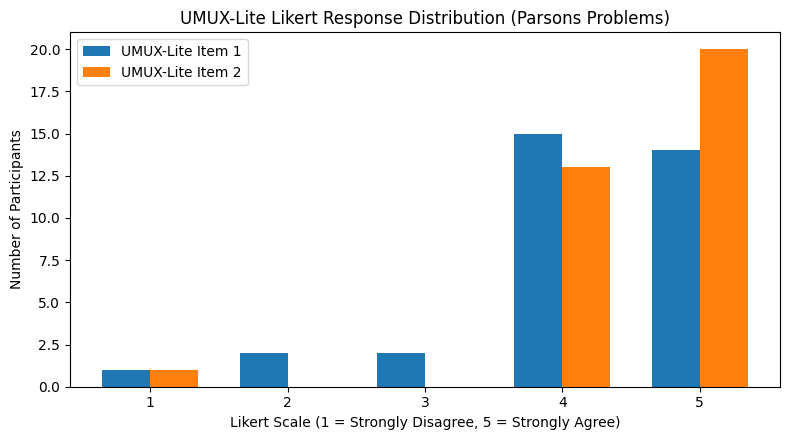


Composite UMUX-Lite (0–100) descriptive stats (optional)
N = 34
Mean = 83.09, SD = 17.65
Median = 87.50, IQR = 25.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------------
# Load data
# -------------------------------
file_path = "Parsons Problem Survey - UMUX.xlsx"
df = pd.read_excel(file_path)

# -------------------------------
# Likert items
# -------------------------------
items = ["UMUX-Lite_1", "UMUX-Lite_2"]
likert_levels = [1, 2, 3, 4, 5]

# -------------------------------
# Descriptive statistics (Likert items)
# -------------------------------
desc = pd.DataFrame({
    "N": df[items].count(),
    "Mean": df[items].mean(),
    "SD": df[items].std(),
    "Median": df[items].median(),
    "Q1": df[items].quantile(0.25),
    "Q3": df[items].quantile(0.75),
    "Min": df[items].min(),
    "Max": df[items].max(),
}).round(3)

print("Descriptive statistics (Likert items)")
print(desc.to_string())

# -------------------------------
# Likert frequency table (counts)
# -------------------------------
counts_q1 = df["UMUX-Lite_1"].value_counts().reindex(likert_levels, fill_value=0)
counts_q2 = df["UMUX-Lite_2"].value_counts().reindex(likert_levels, fill_value=0)

counts_table = pd.DataFrame({
    "Likert": likert_levels,
    "UMUX-Lite_1_count": counts_q1.values,
    "UMUX-Lite_2_count": counts_q2.values
})

print("\nLikert frequency table (counts)")
print(counts_table.to_string(index=False))

# -------------------------------
# Bar chart (side-by-side)
# -------------------------------
x = np.arange(len(likert_levels))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar(x - width/2, counts_q1.values, width, label="UMUX-Lite Item 1")
plt.bar(x + width/2, counts_q2.values, width, label="UMUX-Lite Item 2")

plt.xticks(x, likert_levels)
plt.xlabel("Likert Scale (1 = Strongly Disagree, 5 = Strongly Agree)")
plt.ylabel("Number of Participants")
plt.title("UMUX-Lite Likert Response Distribution (Parsons Problems)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# (Optional) Composite usability score (UMUX-Lite 0–100)
# -------------------------------
df["umux_lite_0_100"] = ((df["UMUX-Lite_1"] + df["UMUX-Lite_2"] - 2) / 8) * 100

mean_u = df["umux_lite_0_100"].mean()
sd_u = df["umux_lite_0_100"].std()
median_u = df["umux_lite_0_100"].median()
iqr_u = stats.iqr(df["umux_lite_0_100"])

print("\nComposite UMUX-Lite (0–100) descriptive stats (optional)")
print(f"N = {len(df)}")
print(f"Mean = {mean_u:.2f}, SD = {sd_u:.2f}")
print(f"Median = {median_u:.2f}, IQR = {iqr_u:.2f}")


Parsons Problem UMUX Score

UMUX-Lite (5-point) Descriptive Statistics
-----------------------------------------
N       = 34
Mean    = 83.09
SD      = 17.65
Median  = 87.50
IQR     = 25.00
Min     = 12.50
Max     = 100.00

Shapiro–Wilk Normality Test
---------------------------
W = 0.769
p = 0.000007


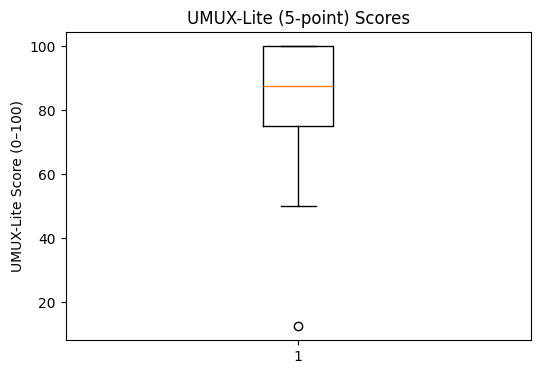

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load the data
# -------------------------------
file_path = "Parsons Problem Survey - UMUX.xlsx"
df = pd.read_excel(file_path)

# -------------------------------
# 2. Compute UMUX-Lite (5-point)
# -------------------------------
# Raw score = Q1 + Q2 - 2
df["umux_raw"] = df["UMUX-Lite_1"] + df["UMUX-Lite_2"] - 2

# Convert to 0–100 scale
df["umux_lite"] = (df["umux_raw"] / 8) * 100

# -------------------------------
# 3. Descriptive statistics
# -------------------------------
mean = df["umux_lite"].mean()
std = df["umux_lite"].std()
median = df["umux_lite"].median()
iqr = stats.iqr(df["umux_lite"])
min_val = df["umux_lite"].min()
max_val = df["umux_lite"].max()

print("UMUX-Lite (5-point) Descriptive Statistics")
print("-----------------------------------------")
print(f"N       = {len(df)}")
print(f"Mean    = {mean:.2f}")
print(f"SD      = {std:.2f}")
print(f"Median  = {median:.2f}")
print(f"IQR     = {iqr:.2f}")
print(f"Min     = {min_val:.2f}")
print(f"Max     = {max_val:.2f}")

# -------------------------------
# 4. Normality test
# -------------------------------
shapiro_stat, shapiro_p = stats.shapiro(df["umux_lite"])

print("\nShapiro–Wilk Normality Test")
print("---------------------------")
print(f"W = {shapiro_stat:.3f}")
print(f"p = {shapiro_p:.6f}")

# -------------------------------
# 5. Visualization (boxplot)
# -------------------------------
plt.figure(figsize=(6, 4))
plt.boxplot(df["umux_lite"])
plt.ylabel("UMUX-Lite Score (0–100)")
plt.title("UMUX-Lite (5-point) Scores")
plt.show()



Parsons Problem - UMUX - SUS Equivalent

In [ ]:
import pandas as pd

# 1. Load your Excel file
# Ensure you have 'openpyxl' installed: pip install openpyxl
file_name = 'Parsons Problem Survey - UMUX.xlsx'
df = pd.read_excel(file_name)

def calculate_sus_equivalent(q1, q2):
    """
    Logic for 5-point UMUX-Lite scale:
    1. Subtract 1 from each item (Range 0-4).
    2. Sum items and scale to 100: (sum * 100 / 8) -> sum * 12.5.
    3. Apply regression formula: (0.65 * score) + 22.9.
    """
    raw_percent = ((q1 - 1) + (q2 - 1)) * 12.5
    sus_equivalent = (0.65 * raw_percent) + 22.9
    return round(sus_equivalent, 2)

# 2. Apply calculation to the dataframe
# Assuming columns are named 'UMUX-Lite_1' and 'UMUX-Lite_2'
df['SUS_Equivalent'] = df.apply(
    lambda row: calculate_sus_equivalent(row['UMUX-Lite_1'], row['UMUX-Lite_2']),
    axis=1
)

# 3. Print the results directly to the console
print("UMUX-Lite to SUS Equivalent Results")
print("=" * 60)
print(df[['Participant ID', 'UMUX-Lite_1', 'UMUX-Lite_2', 'SUS_Equivalent']].to_string(index=False))
print("=" * 60)

# Summary Statistics
mean_sus = df['SUS_Equivalent'].mean()
print(f"Mean SUS Equivalent: {mean_sus:.2f}")
print(f"Standard Deviation:  {df['SUS_Equivalent'].std():.2f}")
print("=" * 60)

UMUX-Lite to SUS Equivalent Results
Participant ID  UMUX-Lite_1  UMUX-Lite_2  SUS_Equivalent
            P1            5            5           87.90
           P10            5            4           79.78
           P11            5            5           87.90
           P12            5            5           87.90
           P13            4            5           79.78
           P14            5            4           79.78
           P15            5            5           87.90
           P16            4            4           71.65
           P17            4            5           79.78
           P18            3            5           71.65
           P19            5            5           87.90
            P2            3            5           71.65
           P20            4            4           71.65
           P21            5            5           87.90
           P22            4            4           71.65
           P23            4            4           7

Parsons Problem UMUX Histogram

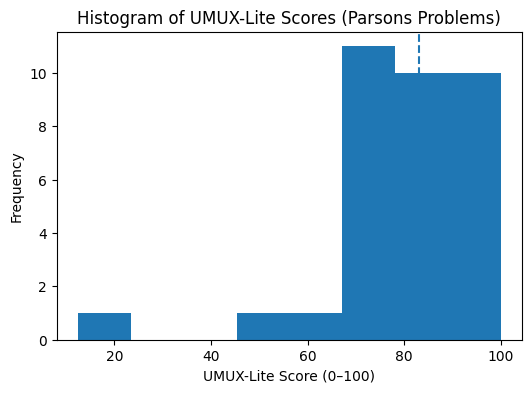

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Parsons UMUX-Lite data
df_parsons = pd.read_excel("Parsons Problem Survey - UMUX.xlsx")

# Compute UMUX-Lite (5-point)
df_parsons["usability_umux_lite"] = (
    (df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8
) * 100

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(df_parsons["usability_umux_lite"], bins=8)
plt.axvline(df_parsons["usability_umux_lite"].mean(), linestyle="--")
plt.xlabel("UMUX-Lite Score (0–100)")
plt.ylabel("Frequency")
plt.title("Histogram of UMUX-Lite Scores (Parsons Problems)")
plt.show()


Traditional Programming UMUX Likert Values

Descriptive statistics (Likert items)
              N   Mean     SD  Median   Q1   Q3  Min  Max
UMUX-Lite_1  34  3.382  1.155     4.0  2.0  4.0    1    5
UMUX-Lite_2  34  2.941  1.205     3.0  2.0  4.0    1    5

Likert frequency table (counts)
 Likert  UMUX-Lite_1_count  UMUX-Lite_2_count
      1                  1                  3
      2                 10                 13
      3                  3                  4
      4                 15                 11
      5                  5                  3


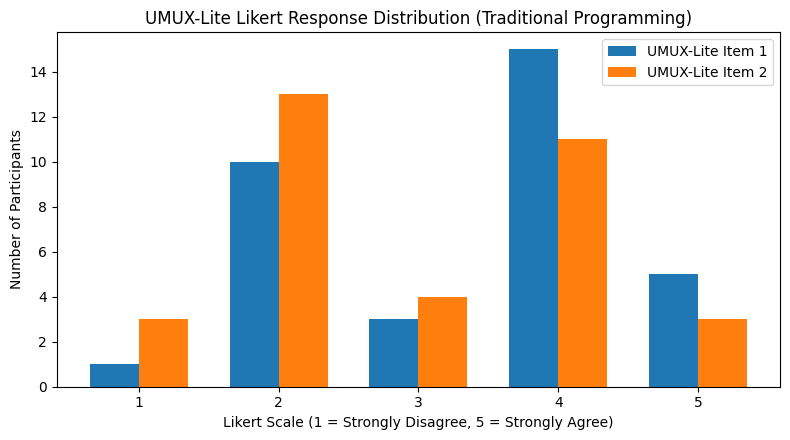


Composite UMUX-Lite (0–100) descriptive stats (optional)
N = 34
Mean = 54.04, SD = 26.95
Median = 56.25, IQR = 50.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------------
# Load data
# -------------------------------
file_path = "Traditional Programming Survey - UMUX.xlsx"
df = pd.read_excel(file_path)

# -------------------------------
# Likert items
# -------------------------------
items = ["UMUX-Lite_1", "UMUX-Lite_2"]
likert_levels = [1, 2, 3, 4, 5]

# -------------------------------
# Descriptive statistics (Likert items)
# -------------------------------
desc = pd.DataFrame({
    "N": df[items].count(),
    "Mean": df[items].mean(),
    "SD": df[items].std(),
    "Median": df[items].median(),
    "Q1": df[items].quantile(0.25),
    "Q3": df[items].quantile(0.75),
    "Min": df[items].min(),
    "Max": df[items].max(),
}).round(3)

print("Descriptive statistics (Likert items)")
print(desc.to_string())

# -------------------------------
# Likert frequency table (counts)
# -------------------------------
counts_q1 = df["UMUX-Lite_1"].value_counts().reindex(likert_levels, fill_value=0)
counts_q2 = df["UMUX-Lite_2"].value_counts().reindex(likert_levels, fill_value=0)

counts_table = pd.DataFrame({
    "Likert": likert_levels,
    "UMUX-Lite_1_count": counts_q1.values,
    "UMUX-Lite_2_count": counts_q2.values
})

print("\nLikert frequency table (counts)")
print(counts_table.to_string(index=False))

# -------------------------------
# Bar chart (side-by-side)
# -------------------------------
x = np.arange(len(likert_levels))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar(x - width/2, counts_q1.values, width, label="UMUX-Lite Item 1")
plt.bar(x + width/2, counts_q2.values, width, label="UMUX-Lite Item 2")

plt.xticks(x, likert_levels)
plt.xlabel("Likert Scale (1 = Strongly Disagree, 5 = Strongly Agree)")
plt.ylabel("Number of Participants")
plt.title("UMUX-Lite Likert Response Distribution (Traditional Programming)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# (Optional) Composite usability score (UMUX-Lite 0–100)
# -------------------------------
df["umux_lite_0_100"] = ((df["UMUX-Lite_1"] + df["UMUX-Lite_2"] - 2) / 8) * 100

mean_u = df["umux_lite_0_100"].mean()
sd_u = df["umux_lite_0_100"].std()
median_u = df["umux_lite_0_100"].median()
iqr_u = stats.iqr(df["umux_lite_0_100"])

print("\nComposite UMUX-Lite (0–100) descriptive stats (optional)")
print(f"N = {len(df)}")
print(f"Mean = {mean_u:.2f}, SD = {sd_u:.2f}")
print(f"Median = {median_u:.2f}, IQR = {iqr_u:.2f}")


Traditional Programming - UMUX Score

UMUX-Lite (5-point) Descriptive Statistics
-----------------------------------------
N       = 34
Mean    = 54.04
SD      = 26.95
Median  = 56.25
IQR     = 50.00
Min     = 12.50
Max     = 100.00

Shapiro–Wilk Normality Test
---------------------------
W = 0.904
p = 0.005756


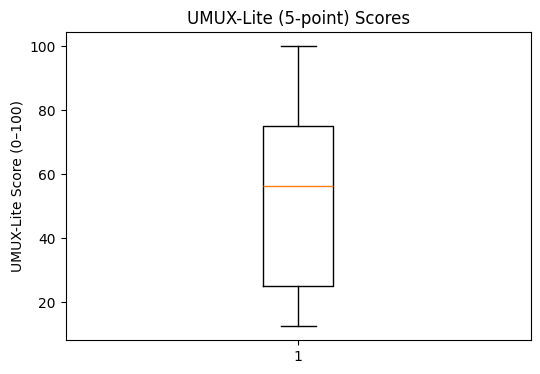

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load the data
# -------------------------------
file_path = "Traditional Programming Survey - UMUX.xlsx"
df = pd.read_excel(file_path)

# -------------------------------
# 2. Compute UMUX-Lite (5-point)
# -------------------------------
# Raw score = Q1 + Q2 - 2
df["umux_raw"] = df["UMUX-Lite_1"] + df["UMUX-Lite_2"] - 2

# Convert to 0–100 scale
df["umux_lite"] = (df["umux_raw"] / 8) * 100

# -------------------------------
# 3. Descriptive statistics
# -------------------------------
mean = df["umux_lite"].mean()
std = df["umux_lite"].std()
median = df["umux_lite"].median()
iqr = stats.iqr(df["umux_lite"])
min_val = df["umux_lite"].min()
max_val = df["umux_lite"].max()

print("UMUX-Lite (5-point) Descriptive Statistics")
print("-----------------------------------------")
print(f"N       = {len(df)}")
print(f"Mean    = {mean:.2f}")
print(f"SD      = {std:.2f}")
print(f"Median  = {median:.2f}")
print(f"IQR     = {iqr:.2f}")
print(f"Min     = {min_val:.2f}")
print(f"Max     = {max_val:.2f}")

# -------------------------------
# 4. Normality test
# -------------------------------
shapiro_stat, shapiro_p = stats.shapiro(df["umux_lite"])

print("\nShapiro–Wilk Normality Test")
print("---------------------------")
print(f"W = {shapiro_stat:.3f}")
print(f"p = {shapiro_p:.6f}")

# -------------------------------
# 5. Visualization (boxplot)
# -------------------------------
plt.figure(figsize=(6, 4))
plt.boxplot(df["umux_lite"])
plt.ylabel("UMUX-Lite Score (0–100)")
plt.title("UMUX-Lite (5-point) Scores")
plt.show()



Traditional Programming UMUX SUS Equivalent

In [ ]:
import pandas as pd

# 1. Load your Excel file
# Ensure you have 'openpyxl' installed: pip install openpyxl
file_name = 'Traditional Programming Survey - UMUX.xlsx'
df = pd.read_excel(file_name)

def calculate_sus_equivalent(q1, q2):
    """
    Logic for 5-point UMUX-Lite scale:
    1. Subtract 1 from each item (Range 0-4).
    2. Sum items and scale to 100: (sum * 100 / 8) -> sum * 12.5.
    3. Apply regression formula: (0.65 * score) + 22.9.
    """
    raw_percent = ((q1 - 1) + (q2 - 1)) * 12.5
    sus_equivalent = (0.65 * raw_percent) + 22.9
    return round(sus_equivalent, 2)

# 2. Apply calculation to the dataframe
# Assuming columns are named 'UMUX-Lite_1' and 'UMUX-Lite_2'
df['SUS_Equivalent'] = df.apply(
    lambda row: calculate_sus_equivalent(row['UMUX-Lite_1'], row['UMUX-Lite_2']),
    axis=1
)

# 3. Print the results directly to the console
print("UMUX-Lite to SUS Equivalent Results")
print("=" * 60)
print(df[['Participant ID', 'UMUX-Lite_1', 'UMUX-Lite_2', 'SUS_Equivalent']].to_string(index=False))
print("=" * 60)

# Summary Statistics
mean_sus = df['SUS_Equivalent'].mean()
print(f"Mean SUS Equivalent: {mean_sus:.2f}")
print(f"Standard Deviation:  {df['SUS_Equivalent'].std():.2f}")
print("=" * 60)

UMUX-Lite to SUS Equivalent Results
Participant ID  UMUX-Lite_1  UMUX-Lite_2  SUS_Equivalent
            P1            5            4           79.78
           P10            5            4           79.78
           P11            4            4           71.65
           P12            4            2           55.40
           P13            4            3           63.52
           P14            2            2           39.15
           P15            3            2           47.27
           P16            2            3           47.27
           P17            5            4           79.78
           P18            4            4           71.65
           P19            4            5           79.78
            P2            5            5           87.90
           P20            4            4           71.65
           P21            3            1           39.15
           P22            2            2           39.15
           P23            2            2           3

Traditional Programming UMUX Histogram

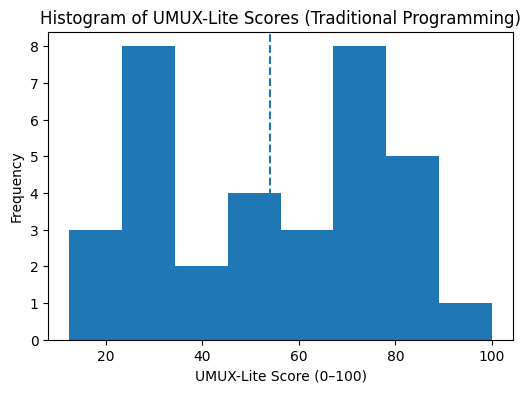

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Traditional Programming UMUX-Lite data
df_trad = pd.read_excel("Traditional Programming Survey - UMUX.xlsx")

# Compute UMUX-Lite (5-point)
df_trad["usability_umux_lite"] = (
    (df_trad["UMUX-Lite_1"] + df_trad["UMUX-Lite_2"] - 2) / 8
) * 100

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(df_trad["usability_umux_lite"], bins=8)
plt.axvline(df_trad["usability_umux_lite"].mean(), linestyle="--")
plt.xlabel("UMUX-Lite Score (0–100)")
plt.ylabel("Frequency")
plt.title("Histogram of UMUX-Lite Scores (Traditional Programming)")
plt.show()


UMUX Box plot

/tmp/ipykernel_595/434725924.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


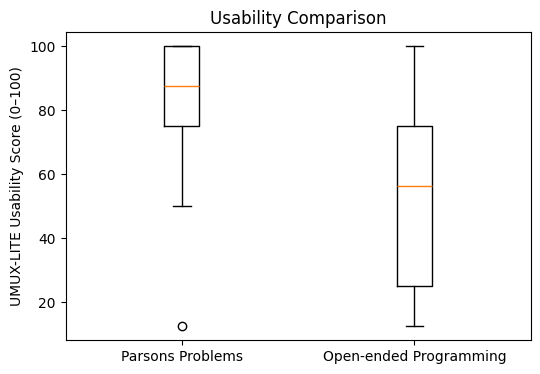

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load data
# -------------------------------
df_parsons = pd.read_excel("Parsons Problem Survey - UMUX.xlsx")
df_traditional = pd.read_excel("Traditional Programming Survey - UMUX.xlsx")

# -------------------------------
# Compute UMUX-Lite score (0–100)
# -------------------------------
df_parsons["umux"] = ((df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8) * 100
df_traditional["umux"] = ((df_traditional["UMUX-Lite_1"] + df_traditional["UMUX-Lite_2"] - 2) / 8) * 100

# -------------------------------
# Combine data
# -------------------------------
data = [df_parsons["umux"], df_traditional["umux"]]

# -------------------------------
# Box plot
# -------------------------------
plt.figure(figsize=(6,4))

plt.boxplot(
    data,
    labels=["Parsons Problems", "Open-ended Programming"]
)

plt.ylabel("UMUX-LITE Usability Score (0–100)")
plt.title("Usability Comparison")

plt.show()

# UMUX - Significance

UMUX Score - Normality

In [ ]:
import pandas as pd
from scipy import stats

# -------------------------------
# Load both datasets
# -------------------------------
df_parsons = pd.read_excel("Parsons Problem Survey - UMUX.xlsx")
df_trad = pd.read_excel("Traditional Programming Survey - UMUX.xlsx")

# -------------------------------
# Compute UMUX-Lite (5-point) for both
# -------------------------------
df_parsons["umux"] = ((df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8) * 100
df_trad["umux"] = ((df_trad["UMUX-Lite_1"] + df_trad["UMUX-Lite_2"] - 2) / 8) * 100

# -------------------------------
# Merge by participant
# -------------------------------
df = df_parsons[["Participant ID", "umux"]].merge(
    df_trad[["Participant ID", "umux"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# -------------------------------
# Compute difference
# -------------------------------
df["umux_diff"] = df["umux_parsons"] - df["umux_traditional"]

# -------------------------------
# Normality test on difference
# -------------------------------
w, p = stats.shapiro(df["umux_diff"])

print("Normality test on UMUX difference (Parsons − Traditional)")
print("--------------------------------------------------------")
print(f"Shapiro–Wilk W = {w:.3f}")
print(f"p-value        = {p:.6f}")


Normality test on UMUX difference (Parsons − Traditional)
--------------------------------------------------------
Shapiro–Wilk W = 0.945
p-value        = 0.084751


UMUX - Histogram

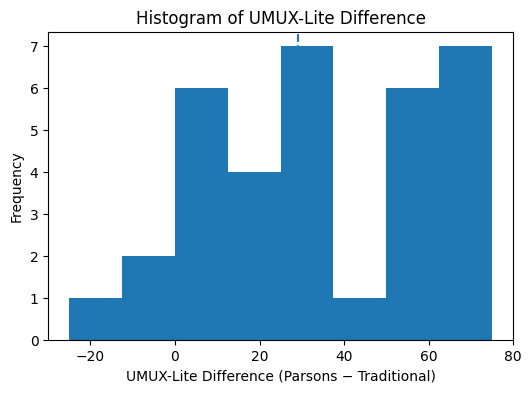

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df_parsons = pd.read_excel("Parsons Problem Survey - UMUX.xlsx")
df_trad = pd.read_excel("Traditional Programming Survey - UMUX.xlsx")

# Compute UMUX-Lite (5-point)
df_parsons["umux"] = ((df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8) * 100
df_trad["umux"] = ((df_trad["UMUX-Lite_1"] + df_trad["UMUX-Lite_2"] - 2) / 8) * 100

# Merge and compute difference
df = df_parsons[["Participant ID", "umux"]].merge(
    df_trad[["Participant ID", "umux"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

df["umux_diff"] = df["umux_parsons"] - df["umux_traditional"]

# -------------------------------
# Histogram
# -------------------------------
plt.figure(figsize=(6, 4))
plt.hist(df["umux_diff"], bins=8)
plt.axvline(df["umux_diff"].mean(), linestyle="--")
plt.xlabel("UMUX-Lite Difference (Parsons − Traditional)")
plt.ylabel("Frequency")
plt.title("Histogram of UMUX-Lite Difference")
plt.show()


UMUX - Paired T test

In [ ]:
import pandas as pd
from scipy import stats

# -------------------------------
# 1) Load both UMUX files
# -------------------------------
parsons_path = "Parsons Problem Survey - UMUX.xlsx"
traditional_path = "Traditional Programming Survey - UMUX.xlsx"

df_parsons = pd.read_excel(parsons_path)
df_trad = pd.read_excel(traditional_path)

# -------------------------------
# 2) Compute UMUX-Lite (5-point) -> 0–100
# -------------------------------
df_parsons["umux_0_100"] = ((df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8) * 100
df_trad["umux_0_100"] = ((df_trad["UMUX-Lite_1"] + df_trad["UMUX-Lite_2"] - 2) / 8) * 100

# -------------------------------
# 3) Merge paired data by participant
# -------------------------------
df = df_parsons[["Participant ID", "umux_0_100"]].merge(
    df_trad[["Participant ID", "umux_0_100"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# -------------------------------
# 4) Compute difference and normality test on difference
# -------------------------------
df["umux_diff"] = df["umux_0_100_parsons"] - df["umux_0_100_traditional"]

w, p_norm = stats.shapiro(df["umux_diff"])
print("Normality test on UMUX difference (Parsons − Traditional)")
print(f"Shapiro–Wilk W = {w:.3f}, p = {p_norm:.6f}")

# -------------------------------
# 5) Paired t-test (because difference is ~normal)
# -------------------------------
t_stat, p_val = stats.ttest_rel(df["umux_0_100_parsons"], df["umux_0_100_traditional"])

# -------------------------------
# 6) Effect size: Cohen's d for paired samples
# -------------------------------
mean_diff = df["umux_diff"].mean()
sd_diff = df["umux_diff"].std(ddof=1)
cohens_d = mean_diff / sd_diff

# -------------------------------
# 7) Print results
# -------------------------------
print("\nPaired t-test: UMUX (Parsons vs Traditional)")
print("------------------------------------------")
print(f"N = {len(df)}")
print(f"Parsons Mean = {df['umux_0_100_parsons'].mean():.2f}, SD = {df['umux_0_100_parsons'].std(ddof=1):.2f}")
print(f"Traditional Mean = {df['umux_0_100_traditional'].mean():.2f}, SD = {df['umux_0_100_traditional'].std(ddof=1):.2f}")
print(f"Mean Diff (Parsons−Traditional) = {mean_diff:.2f}")
print(f"t({len(df)-1}) = {t_stat:.3f}, p = {p_val:.6f}")
print(f"Cohen's d (paired) = {cohens_d:.3f}")

# -------------------------------
# (Optional) If you prefer Wilcoxon as a robustness check
# -------------------------------
w_stat, p_wil = stats.wilcoxon(df["umux_0_100_parsons"], df["umux_0_100_traditional"])
print("\nWilcoxon signed-rank (robustness check)")
print("--------------------------------------")
print(f"W = {w_stat:.3f}, p = {p_wil:.6f}")

Normality test on UMUX difference (Parsons − Traditional)
Shapiro–Wilk W = 0.945, p = 0.084751

Paired t-test: UMUX (Parsons vs Traditional)
------------------------------------------
N = 34
Parsons Mean = 83.09, SD = 17.65
Traditional Mean = 54.04, SD = 26.95
Mean Diff (Parsons−Traditional) = 29.04
t(33) = 6.015, p = 0.000001
Cohen's d (paired) = 1.032

Wilcoxon signed-rank (robustness check)
--------------------------------------
W = 17.500, p = 0.000022


UMUX Wilcoxon Test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# -------------------------------
# 1. Load data
# -------------------------------
df_parsons = pd.read_excel("Parsons Problem Survey - UMUX.xlsx")
df_traditional = pd.read_excel("Traditional Programming Survey - UMUX.xlsx")

# -------------------------------
# 2. Compute UMUX-Lite (5-point -> 0–100)
# -------------------------------
df_parsons["umux"] = ((df_parsons["UMUX-Lite_1"] + df_parsons["UMUX-Lite_2"] - 2) / 8) * 100
df_traditional["umux"] = ((df_traditional["UMUX-Lite_1"] + df_traditional["UMUX-Lite_2"] - 2) / 8) * 100

# -------------------------------
# 3. Merge paired data
# -------------------------------
df = df_parsons[["Participant ID", "umux"]].merge(
    df_traditional[["Participant ID", "umux"]],
    on="Participant ID",
    suffixes=("_parsons", "_traditional")
)

# -------------------------------
# 4. Wilcoxon signed-rank test
# -------------------------------
w_stat, p_value = stats.wilcoxon(
    df["umux_parsons"],
    df["umux_traditional"]
)

# -------------------------------
# 5. Effect size r
# r = Z / sqrt(N)
# -------------------------------

# Compute Z manually
n = len(df)
mean_w = n * (n + 1) / 4
sd_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
z = (w_stat - mean_w) / sd_w
r = abs(z) / np.sqrt(n)

# -------------------------------
# 6. Print results
# -------------------------------
print("Wilcoxon Signed-Rank Test (UMUX Parsons vs Traditional)")
print("-------------------------------------------------------")
print(f"N = {n}")
print(f"W = {w_stat:.3f}")
print(f"p = {p_value:.6f}")
print(f"Z = {z:.3f}")
print(f"Effect size r = {r:.3f}")

Wilcoxon Signed-Rank Test (UMUX Parsons vs Traditional)
-------------------------------------------------------
N = 34
W = 17.500
p = 0.000022
Z = -4.787
Effect size r = 0.821


# CMDQ - PP and TP

Parsons Problem CMDQ Likert Values


CMDQ Ergonomics – Likert Frequency Table (Counts)
Rows = discomfort level, Columns = body parts/items

                          QID2_1  QID2_2  QID2_3  QID2_4  QID2_5
None                          21      30      32      32      27
Slightly uncomfortable        13       4       1       1       5
Moderately uncomfortable       0       0       1       1       2
Very uncomfortable             0       0       0       0       0


<Figure size 1000x600 with 0 Axes>

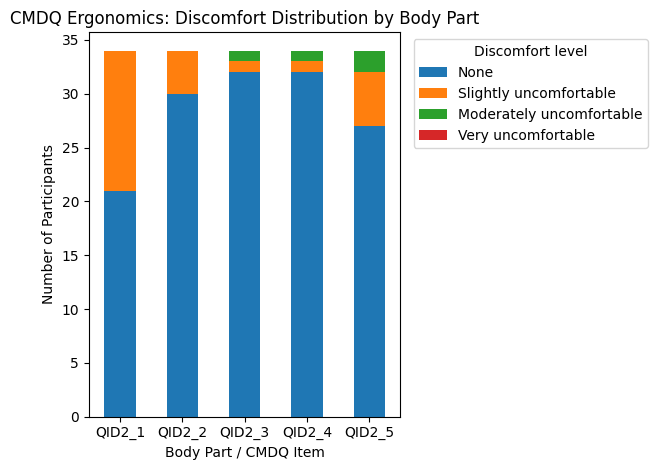

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CMDQ Ergonomics: Frequency stats + bar chart
# Body parts: neck, shoulder, arm, wrist, back
# Scale: 0=None, 1=Slightly, 2=Moderately, 3=Very uncomfortable
# ============================

# 1) Load your Excel file
file_path = "Parsons Problem Survey - CMDQ.xlsx"
df = pd.read_excel(file_path)

# 2) Pick the correct CMDQ columns
# Option A (recommended): if your columns are named like this
preferred_cols = ["Neck", "Shoulder", "Arm", "Wrist", "Back"]

# Option B: if your file uses different names (e.g., QID2_1 ...),
# update this list to match your actual column names.
fallback_cols = ["QID2_1", "QID2_2", "QID2_3", "QID2_4", "QID2_5"]

cmdq_cols = preferred_cols if all(c in df.columns for c in preferred_cols) else fallback_cols
cmdq_df = df[cmdq_cols].copy()

# 3) Define Likert labels (edit if your data uses text instead of numbers)
likert_labels = {
    0: "None",
    1: "Slightly uncomfortable",
    2: "Moderately uncomfortable",
    3: "Very uncomfortable"
}

# 4) Frequency table (counts) for each Likert value per body part/item
# Force all 4 levels to appear even if some are missing in the data
levels = [0, 1, 2, 3]
freq = pd.DataFrame(
    {col: cmdq_df[col].value_counts(dropna=False) for col in cmdq_df.columns}
).fillna(0).astype(int)

freq = freq.reindex(levels, fill_value=0)

# Add readable row labels
freq.index = [likert_labels[v] for v in freq.index]

print("\nCMDQ Ergonomics – Likert Frequency Table (Counts)")
print("Rows = discomfort level, Columns = body parts/items\n")
print(freq)

# 5) Bar chart (stacked) showing distribution of Likert responses per body part/item
plt.figure(figsize=(10, 6))
freq.T.plot(kind="bar", stacked=True)

plt.xlabel("Body Part / CMDQ Item")
plt.ylabel("Number of Participants")
plt.title("CMDQ Ergonomics: Discomfort Distribution by Body Part")
plt.xticks(rotation=0)
plt.legend(title="Discomfort level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Traditional Programming CMDQ Likert Values


CMDQ Ergonomics – Likert Frequency Table (Counts)
Rows = discomfort level, Columns = body parts/items

                          QID2_1  QID2_2  QID2_3  QID2_4  QID2_5
None                          16      31      30      27      25
Slightly uncomfortable        12       1       3       5       5
Moderately uncomfortable       6       2       1       1       2
Very uncomfortable             0       0       0       1       2


<Figure size 1000x600 with 0 Axes>

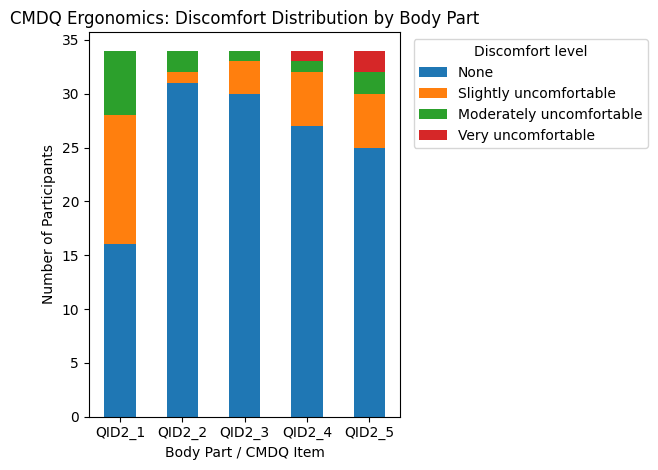

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CMDQ Ergonomics: Frequency stats + bar chart
# Body parts: neck, shoulder, arm, wrist, back
# Scale: 0=None, 1=Slightly, 2=Moderately, 3=Very uncomfortable
# ============================

# 1) Load your Excel file
file_path = "Traditional Programming Survey - CMDQ.xlsx"
df = pd.read_excel(file_path)

# 2) Pick the correct CMDQ columns
# Option A (recommended): if your columns are named like this
preferred_cols = ["Neck", "Shoulder", "Arm", "Wrist", "Back"]

# Option B: if your file uses different names (e.g., QID2_1 ...),
# update this list to match your actual column names.
fallback_cols = ["QID2_1", "QID2_2", "QID2_3", "QID2_4", "QID2_5"]

cmdq_cols = preferred_cols if all(c in df.columns for c in preferred_cols) else fallback_cols
cmdq_df = df[cmdq_cols].copy()

# 3) Define Likert labels (edit if your data uses text instead of numbers)
likert_labels = {
    0: "None",
    1: "Slightly uncomfortable",
    2: "Moderately uncomfortable",
    3: "Very uncomfortable"
}

# 4) Frequency table (counts) for each Likert value per body part/item
# Force all 4 levels to appear even if some are missing in the data
levels = [0, 1, 2, 3]
freq = pd.DataFrame(
    {col: cmdq_df[col].value_counts(dropna=False) for col in cmdq_df.columns}
).fillna(0).astype(int)

freq = freq.reindex(levels, fill_value=0)

# Add readable row labels
freq.index = [likert_labels[v] for v in freq.index]

print("\nCMDQ Ergonomics – Likert Frequency Table (Counts)")
print("Rows = discomfort level, Columns = body parts/items\n")
print(freq)

# 5) Bar chart (stacked) showing distribution of Likert responses per body part/item
plt.figure(figsize=(10, 6))
freq.T.plot(kind="bar", stacked=True)

plt.xlabel("Body Part / CMDQ Item")
plt.ylabel("Number of Participants")
plt.title("CMDQ Ergonomics: Discomfort Distribution by Body Part")
plt.xticks(rotation=0)
plt.legend(title="Discomfort level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Parsons VS Traditional CMDQ


CMDQ Comparison Table

           Neck (Parsons) Neck (Traditional) Shoulder (Parsons)  \
None           21 (61.8%)         16 (47.1%)         30 (88.2%)   
Slightly       13 (38.2%)         12 (35.3%)          4 (11.8%)   
Moderately       0 (0.0%)          6 (17.6%)           0 (0.0%)   
Very             0 (0.0%)           0 (0.0%)           0 (0.0%)   

           Shoulder (Traditional) Arm (Parsons) Arm (Traditional)  \
None                   31 (91.2%)    32 (94.1%)        30 (88.2%)   
Slightly                 1 (2.9%)      1 (2.9%)          3 (8.8%)   
Moderately               2 (5.9%)      1 (2.9%)          1 (2.9%)   
Very                     0 (0.0%)      0 (0.0%)          0 (0.0%)   

           Wrist (Parsons) Wrist (Traditional) Back (Parsons)  \
None            32 (94.1%)          27 (79.4%)     27 (79.4%)   
Slightly          1 (2.9%)           5 (14.7%)      5 (14.7%)   
Moderately        1 (2.9%)            1 (2.9%)       2 (5.9%)   
Very              0 (0.0%)        

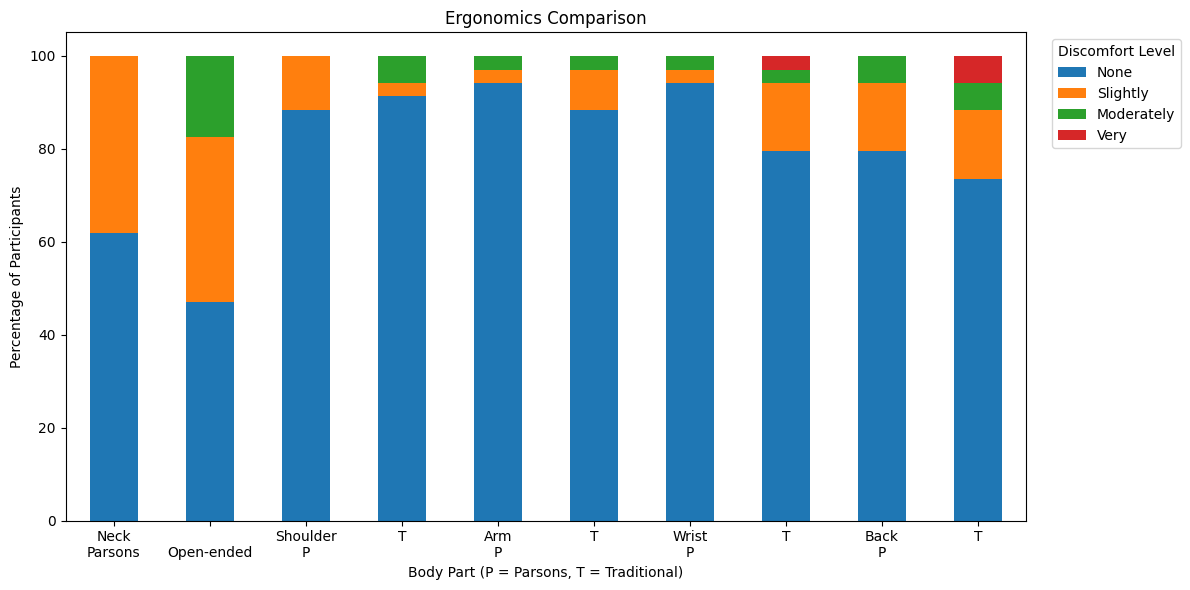

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load files
# =========================
parsons_path = "Parsons Problem Survey - CMDQ.xlsx"
traditional_path = "Traditional Programming Survey - CMDQ.xlsx"

parsons = pd.read_excel(parsons_path)
traditional = pd.read_excel(traditional_path)

# =========================
# CMDQ columns
# =========================
cols = ["QID2_1", "QID2_2", "QID2_3", "QID2_4", "QID2_5"]
body_parts = ["Neck", "Shoulder", "Arm", "Wrist", "Back"]

levels = [0, 1, 2, 3]
labels = ["None", "Slightly", "Moderately", "Very"]

# =========================
# Build comparison table
# =========================
table_data = {}

for col, part in zip(cols, body_parts):
    p_counts = parsons[col].value_counts().reindex(levels, fill_value=0)
    t_counts = traditional[col].value_counts().reindex(levels, fill_value=0)

    p_perc = (p_counts / p_counts.sum() * 100).round(1)
    t_perc = (t_counts / t_counts.sum() * 100).round(1)

    table_data[f"{part} (Parsons)"] = [
        f"{p_counts.iloc[i]} ({p_perc.iloc[i]}%)" for i in range(len(levels))
    ]
    table_data[f"{part} (Traditional)"] = [
        f"{t_counts.iloc[i]} ({t_perc.iloc[i]}%)" for i in range(len(levels))
    ]

comparison_table = pd.DataFrame(table_data, index=labels)

print("\nCMDQ Comparison Table\n")
print(comparison_table)

# =========================
# Build plotting dataframe
# =========================
rows = []

for col, part in zip(cols, body_parts):
    p_counts = parsons[col].value_counts().reindex(levels, fill_value=0)
    t_counts = traditional[col].value_counts().reindex(levels, fill_value=0)

    p_perc = (p_counts / p_counts.sum() * 100).round(1)
    t_perc = (t_counts / t_counts.sum() * 100).round(1)

    rows.append([part, "Parsons Problem"] + p_perc.tolist())
    rows.append([part, "Open-ended Programming"] + t_perc.tolist())

df_plot = pd.DataFrame(rows, columns=["Body Part", "Condition"] + labels)
df_plot["Label"] = df_plot["Body Part"] + " (" + df_plot["Condition"] + ")"
df_plot = df_plot.set_index("Label")[labels]

# =========================
# Plot stacked percentage chart
# =========================
ax = df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Percentage of Participants")
plt.xlabel("Body Part and Condition")
plt.title("Ergonomics Comparison")
labels = [
    "Neck\nParsons","\nOpen-ended",
    "Shoulder\nP","T",
    "Arm\nP","T",
    "Wrist\nP","T",
    "Back\nP","T"
]


plt.xticks(range(len(labels)), labels, rotation=0)
plt.xlabel("Body Part (P = Parsons, T = Traditional)")

#plt.xticks(rotation=45, ha="right")
plt.legend(title="Discomfort Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

CMDQ - Percentage - Bar chart


CMDQ Table (Frequency + Percentage)

Body Part   Condition       None   Slightly Moderately     Very
     Neck     Parsons 21 (61.8%) 13 (38.2%)   0 (0.0%) 0 (0.0%)
     Neck Traditional 16 (47.1%) 12 (35.3%)  6 (17.6%) 0 (0.0%)
 Shoulder     Parsons 30 (88.2%)  4 (11.8%)   0 (0.0%) 0 (0.0%)
 Shoulder Traditional 31 (91.2%)   1 (2.9%)   2 (5.9%) 0 (0.0%)
      Arm     Parsons 32 (94.1%)   1 (2.9%)   1 (2.9%) 0 (0.0%)
      Arm Traditional 30 (88.2%)   3 (8.8%)   1 (2.9%) 0 (0.0%)
    Wrist     Parsons 32 (94.1%)   1 (2.9%)   1 (2.9%) 0 (0.0%)
    Wrist Traditional 27 (79.4%)  5 (14.7%)   1 (2.9%) 1 (2.9%)
     Back     Parsons 27 (79.4%)  5 (14.7%)   2 (5.9%) 0 (0.0%)
     Back Traditional 25 (73.5%)  5 (14.7%)   2 (5.9%) 2 (5.9%)


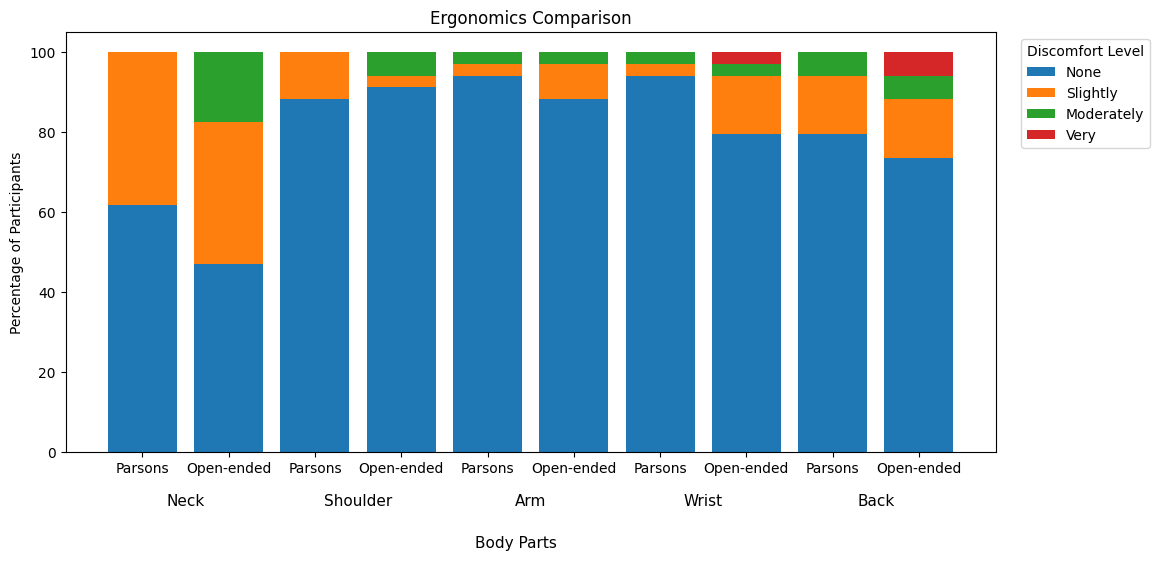

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load files
# -----------------------------
parsons_file = "Parsons Problem Survey - CMDQ.xlsx"
traditional_file = "Traditional Programming Survey - CMDQ.xlsx"

parsons = pd.read_excel(parsons_file)
traditional = pd.read_excel(traditional_file)

# -----------------------------
# CMDQ columns
# -----------------------------
cols = ["QID2_1", "QID2_2", "QID2_3", "QID2_4", "QID2_5"]
body_parts = ["Neck", "Shoulder", "Arm", "Wrist", "Back"]

levels = [0, 1, 2, 3]
labels = ["None", "Slightly", "Moderately", "Very"]

table_rows = []
plot_data = []

# -----------------------------
# Build table and percentage data
# -----------------------------
for col, part in zip(cols, body_parts):
    p_counts = parsons[col].value_counts().reindex(levels, fill_value=0)
    t_counts = traditional[col].value_counts().reindex(levels, fill_value=0)

    p_perc = (p_counts / p_counts.sum() * 100).round(1)
    t_perc = (t_counts / t_counts.sum() * 100).round(1)

    row_p = {"Body Part": part, "Condition": "Parsons"}
    row_t = {"Body Part": part, "Condition": "Traditional"}

    for val, lab in zip(levels, labels):
        row_p[lab] = f"{p_counts[val]} ({p_perc[val]}%)"
        row_t[lab] = f"{t_counts[val]} ({t_perc[val]}%)"

    table_rows.append(row_p)
    table_rows.append(row_t)

    plot_data.append(p_perc.values)
    plot_data.append(t_perc.values)

# -----------------------------
# Print table
# -----------------------------
table = pd.DataFrame(table_rows)
print("\nCMDQ Table (Frequency + Percentage)\n")
print(table.to_string(index=False))

# -----------------------------
# Plot percentage stacked bars
# -----------------------------
df = pd.DataFrame(plot_data, columns=labels)
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(df))
for level in labels:
    ax.bar(x, df[level], bottom=bottom, label=level)
    bottom += df[level].values

# P / T labels under bars
ax.set_xticks(x)
ax.set_xticklabels(["Parsons", "Open-ended", "Parsons", "Open-ended", "Parsons", "Open-ended", "Parsons", "Open-ended", "Parsons", "Open-ended"], fontsize=10)

# Body-part labels centered below each pair
centers = [0.5, 2.5, 4.5, 6.5, 8.5]
for c, part in zip(centers, body_parts):
    ax.text(c, -0.10, part, ha="center", va="top", fontsize=11, transform=ax.get_xaxis_transform())

ax.set_ylabel("Percentage of Participants")
ax.set_title("Ergonomics Comparison")
ax.set_ylim(0, 105)

# Remove xlabel to avoid overlap
# ax.set_xlabel("Body Part (P = Parsons, T = Traditional)")

# Add small note instead
fig.text(0.5, 0.02, "Body Parts", ha="center", fontsize=11)

ax.legend(title="Discomfort Level", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.subplots_adjust(bottom=0.18)
plt.show()

# CMDQ - Significance

CMDQ Wilcoxon Test

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon
import numpy as np

# Load data
parsons_path = "Parsons Problem Survey - CMDQ.xlsx"
trad_path    = "Traditional Programming Survey - CMDQ.xlsx"

parsons_df = pd.read_excel(parsons_path)
trad_df    = pd.read_excel(trad_path)

# Detect columns
cols = ["QID2_1", "QID2_2", "QID2_3", "QID2_4", "QID2_5"]

results = []

for col in cols:
    p = parsons_df[col]
    t = trad_df[col]

    stat, p_value = wilcoxon(p, t)

    # Effect size r = Z / sqrt(N)
    # Approximate Z from Wilcoxon statistic
    n = len(p)
    z = (stat - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)
    r = abs(z) / np.sqrt(n)

    results.append({
        "Body Part": col,
        "W Statistic": stat,
        "p-value": round(p_value, 4),
        "Effect size r": round(r, 3)
    })

results_df = pd.DataFrame(results)
print("\nWilcoxon Signed-Rank Results (Parsons vs Traditional)")
print(results_df)

#neck, shoulder, arm, wrist, back


Wilcoxon Signed-Rank Results (Parsons vs Traditional)
  Body Part  W Statistic  p-value  Effect size r
0    QID2_1         14.0   0.0076          0.831
1    QID2_2          4.0   0.7055          0.861
2    QID2_3          1.5   0.4142          0.868
3    QID2_4          0.0   0.0339          0.872
4    QID2_5          7.0   0.1067          0.852


# CSCL - PP and TP

Parsons Problem CSCL

Rows total: 34
Rows valid for IL scoring: 34

Cronbach's alpha (IL items): 0.965

Intrinsic Load (IL) Descriptives:
     N: 34
  Mean: 1.1764705882352942
    SD: 1.5917195117731138
Median: 0.6666666666666666
    Q1: 0.0
    Q3: 1.9166666666666667
   IQR: 1.9166666666666667
   Min: 0.0
   Max: 7.333333333333333

Shapiro–Wilk for IL_score: W=0.7331, p=1.648e-06


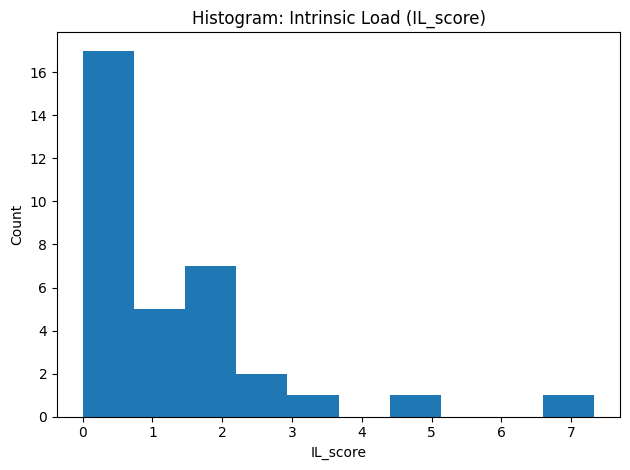

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1) Load data
# =========================
FILE_PATH = "Parsons Problem Survey - CSCL.xlsx"
SHEET_NAME = 0  # or "Sheet0"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Your Intrinsic Load (IL) item columns in this file:
IL_ITEMS = ["Cognitive Load_1", "Cognitive Load_2", "Cognitive Load_3"]

# Basic checks
missing_cols = [c for c in IL_ITEMS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected IL columns: {missing_cols}. Found columns: {list(df.columns)}")

# Ensure numeric
for c in IL_ITEMS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# 2) Compute IL score
#    (mean of the 3 items)
# =========================
df["IL_score"] = df[IL_ITEMS].mean(axis=1, skipna=True)

# Optional: flag rows with too much missing
df["IL_valid_items"] = df[IL_ITEMS].notna().sum(axis=1)
df["IL_is_valid"] = df["IL_valid_items"] >= 2   # at least 2 of 3 answered

# If you prefer strict scoring (require all 3 answered), change to:
# df["IL_is_valid"] = df["IL_valid_items"] == 3

df_valid = df[df["IL_is_valid"]].copy()

print("Rows total:", len(df))
print("Rows valid for IL scoring:", len(df_valid))

# =========================
# 3) Reliability: Cronbach's alpha
# =========================
def cronbach_alpha(dataframe: pd.DataFrame) -> float:
    """
    Cronbach's alpha for a set of items (columns).
    Drops rows with any missing values among the items.
    """
    x = dataframe.dropna().to_numpy(dtype=float)
    k = x.shape[1]
    if k < 2:
        return np.nan
    item_vars = x.var(axis=0, ddof=1)
    total_scores = x.sum(axis=1)
    total_var = total_scores.var(ddof=1)
    if total_var == 0:
        return np.nan
    alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
    return float(alpha)

alpha_il = cronbach_alpha(df_valid[IL_ITEMS])
print(f"\nCronbach's alpha (IL items): {alpha_il:.3f}")

# =========================
# 4) Descriptive statistics for IL
# =========================
il = df_valid["IL_score"].dropna()

desc = {
    "N": int(il.shape[0]),
    "Mean": float(il.mean()),
    "SD": float(il.std(ddof=1)),
    "Median": float(il.median()),
    "Q1": float(il.quantile(0.25)),
    "Q3": float(il.quantile(0.75)),
    "IQR": float(il.quantile(0.75) - il.quantile(0.25)),
    "Min": float(il.min()),
    "Max": float(il.max()),
}

print("\nIntrinsic Load (IL) Descriptives:")
for k, v in desc.items():
    print(f"{k:>6}: {v}")

# =========================
# 5) Normality test (Shapiro–Wilk)
# =========================
# Note: Shapiro is fine for n<=5000 typically. For large n, consider QQ plot + other tests.
if len(il) >= 3:
    shapiro_stat, shapiro_p = stats.shapiro(il)
    print(f"\nShapiro–Wilk for IL_score: W={shapiro_stat:.4f}, p={shapiro_p:.4g}")
else:
    print("\nNot enough data for Shapiro–Wilk (need >=3).")

# =========================
# 6) Histogram (save + show)
# =========================
plt.figure()
plt.hist(il, bins=10)  # do not set colors (keeps defaults)
plt.title("Histogram: Intrinsic Load (IL_score)")
plt.xlabel("IL_score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()






Traditional Programming CSCL

Rows total: 34
Rows valid for IL scoring: 34

Cronbach's alpha (IL items): 0.947

Intrinsic Load (IL) Descriptives:
     N: 34
  Mean: 2.0
    SD: 1.8072059279432617
Median: 1.8333333333333335
    Q1: 0.41666666666666663
    Q3: 2.9166666666666665
   IQR: 2.5
   Min: 0.0
   Max: 5.666666666666667

Shapiro–Wilk for IL_score: W=0.8761, p=0.001133


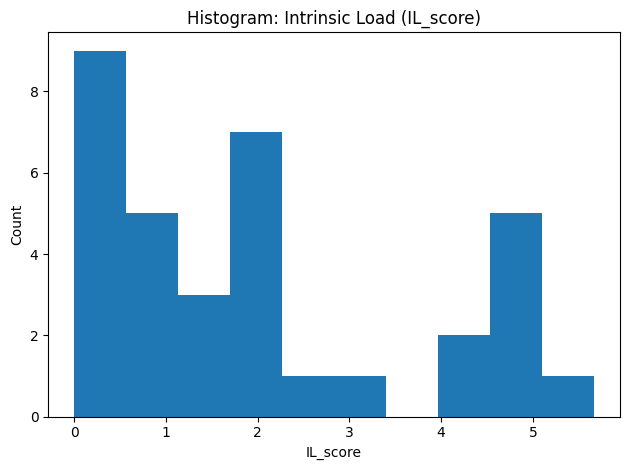

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1) Load data
# =========================
FILE_PATH = "Traditional Programming Survey - CSCL.xlsx"
SHEET_NAME = 0  # or "Sheet0"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Your Intrinsic Load (IL) item columns in this file:
IL_ITEMS = ["Cognitive Load_1", "Cognitive Load_2", "Cognitive Load_3"]

# Basic checks
missing_cols = [c for c in IL_ITEMS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected IL columns: {missing_cols}. Found columns: {list(df.columns)}")

# Ensure numeric
for c in IL_ITEMS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# 2) Compute IL score
#    (mean of the 3 items)
# =========================
df["IL_score"] = df[IL_ITEMS].mean(axis=1, skipna=True)

# Optional: flag rows with too much missing
df["IL_valid_items"] = df[IL_ITEMS].notna().sum(axis=1)
df["IL_is_valid"] = df["IL_valid_items"] >= 2   # at least 2 of 3 answered

# If you prefer strict scoring (require all 3 answered), change to:
# df["IL_is_valid"] = df["IL_valid_items"] == 3

df_valid = df[df["IL_is_valid"]].copy()

print("Rows total:", len(df))
print("Rows valid for IL scoring:", len(df_valid))

# =========================
# 3) Reliability: Cronbach's alpha
# =========================
def cronbach_alpha(dataframe: pd.DataFrame) -> float:
    """
    Cronbach's alpha for a set of items (columns).
    Drops rows with any missing values among the items.
    """
    x = dataframe.dropna().to_numpy(dtype=float)
    k = x.shape[1]
    if k < 2:
        return np.nan
    item_vars = x.var(axis=0, ddof=1)
    total_scores = x.sum(axis=1)
    total_var = total_scores.var(ddof=1)
    if total_var == 0:
        return np.nan
    alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
    return float(alpha)

alpha_il = cronbach_alpha(df_valid[IL_ITEMS])
print(f"\nCronbach's alpha (IL items): {alpha_il:.3f}")

# =========================
# 4) Descriptive statistics for IL
# =========================
il = df_valid["IL_score"].dropna()

desc = {
    "N": int(il.shape[0]),
    "Mean": float(il.mean()),
    "SD": float(il.std(ddof=1)),
    "Median": float(il.median()),
    "Q1": float(il.quantile(0.25)),
    "Q3": float(il.quantile(0.75)),
    "IQR": float(il.quantile(0.75) - il.quantile(0.25)),
    "Min": float(il.min()),
    "Max": float(il.max()),
}

print("\nIntrinsic Load (IL) Descriptives:")
for k, v in desc.items():
    print(f"{k:>6}: {v}")

# =========================
# 5) Normality test (Shapiro–Wilk)
# =========================
# Note: Shapiro is fine for n<=5000 typically. For large n, consider QQ plot + other tests.
if len(il) >= 3:
    shapiro_stat, shapiro_p = stats.shapiro(il)
    print(f"\nShapiro–Wilk for IL_score: W={shapiro_stat:.4f}, p={shapiro_p:.4g}")
else:
    print("\nNot enough data for Shapiro–Wilk (need >=3).")

# =========================
# 6) Histogram (save + show)
# =========================
plt.figure()
plt.hist(il, bins=10)  # do not set colors (keeps defaults)
plt.title("Histogram: Intrinsic Load (IL_score)")
plt.xlabel("IL_score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Parsons Problem vs Traditional Programming Boxplot

/tmp/ipython-input-3963596967.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


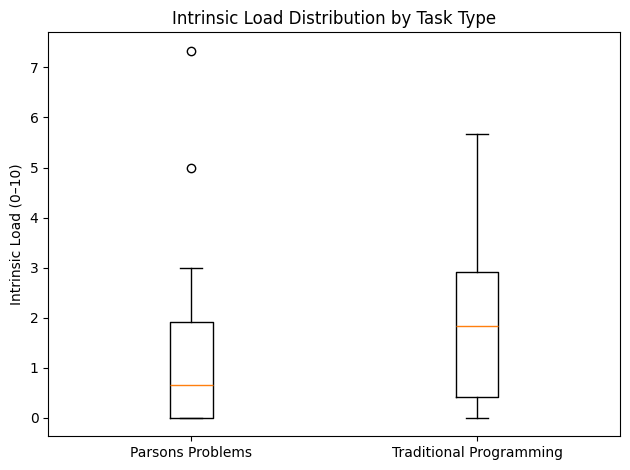

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both datasets
parsons_path = "Parsons Problem Survey - CSCL.xlsx"
traditional_path = "Traditional Programming Survey - CSCL.xlsx"

parsons = pd.read_excel(parsons_path)
traditional = pd.read_excel(traditional_path)

IL_ITEMS = ["Cognitive Load_1", "Cognitive Load_2", "Cognitive Load_3"]

# Ensure numeric and compute IL score
for df in [parsons, traditional]:
    for c in IL_ITEMS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["IL_score"] = df[IL_ITEMS].mean(axis=1)

# Prepare data for boxplot
data = [
    parsons["IL_score"].dropna(),
    traditional["IL_score"].dropna()
]

labels = ["Parsons Problems", "Traditional Programming"]

# Create box plot
plt.figure()
plt.boxplot(data, labels=labels)
plt.ylabel("Intrinsic Load (0–10)")
plt.title("Intrinsic Load Distribution by Task Type")
plt.tight_layout()
plt.show()


# CSCL - Significance

CSCL - Normality Test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load merged paired data (reuse previous merge if available)
parsons_path = "Parsons Problem Survey - CSCL.xlsx"
trad_path    = "Traditional Programming Survey - CSCL.xlsx"

p = pd.read_excel(parsons_path)
t = pd.read_excel(trad_path)

IL_ITEMS = ["Cognitive Load_1", "Cognitive Load_2", "Cognitive Load_3"]
ID_COL = "Participant ID"

for df in [p, t]:
    for c in IL_ITEMS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["IL_score"] = df[IL_ITEMS].mean(axis=1)

p = p[[ID_COL, "IL_score"]].rename(columns={"IL_score": "IL_Parsons"})
t = t[[ID_COL, "IL_score"]].rename(columns={"IL_score": "IL_Traditional"})

m = p.merge(t, on=ID_COL, how="inner").dropna()

diff = m["IL_Parsons"] - m["IL_Traditional"]

# Shapiro test on DIFFERENCE
W, p_value = stats.shapiro(diff)

print("Shapiro test on difference scores:")
print("W =", W)
print("p =", p_value)

Shapiro test on difference scores:
W = 0.8803704935225668
p = 0.00144613076828965


CSCL - Wilcoxon Test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# -----------------------
# Load both files
# -----------------------
parsons_path = "Parsons Problem Survey - CSCL.xlsx"
trad_path    = "Traditional Programming Survey - CSCL.xlsx"

p = pd.read_excel(parsons_path)
t = pd.read_excel(trad_path)

ID_COL = "Participant ID"
IL_ITEMS = ["Cognitive Load_1", "Cognitive Load_2", "Cognitive Load_3"]

# Ensure numeric + compute IL
for df in [p, t]:
    for c in IL_ITEMS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["IL_score"] = df[IL_ITEMS].mean(axis=1)

# Keep only ID + score
p = p[[ID_COL, "IL_score"]].rename(columns={"IL_score": "IL_Parsons"})
t = t[[ID_COL, "IL_score"]].rename(columns={"IL_score": "IL_Traditional"})

# Merge paired data
m = p.merge(t, on=ID_COL, how="inner").dropna()
diff = m["IL_Parsons"] - m["IL_Traditional"]

print("N paired:", len(m))
print("Median difference (Parsons - Traditional):", float(diff.median()))

# -----------------------
# Wilcoxon signed-rank
# -----------------------
w_stat, p_value = stats.wilcoxon(m["IL_Parsons"], m["IL_Traditional"], zero_method="wilcox", alternative="two-sided")

# Compute Z approx for effect size r
# (normal approximation commonly used in reporting)
n = len(m)
mean_w = n*(n+1)/4
sd_w = np.sqrt(n*(n+1)*(2*n+1)/24)
z = (w_stat - mean_w) / sd_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon: W={w_stat:.3f}, p={p_value:.6f}")
print(f"Effect size: Z={z:.3f}, r={r:.3f}")

N paired: 34
Median difference (Parsons - Traditional): -0.33333333333333326
Wilcoxon: W=40.000, p=0.001656
Effect size: Z=-4.402, r=0.755


# IRR Measures

IRR Measure - Parsons Problem Comments



In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# =========================
# CONFIG (edit if needed)
# =========================
file_linta = "Parsons Problem Adv Disadv - Linta.xlsx"
file_taskin = "Parsons Problem Adv Disadv - Taskin.xlsx"

id_col = "Participant ID"   # change if your ID column name differs
sheet_linta = None          # e.g., "Sheet1" if needed
sheet_taskin = None         # e.g., "Sheet1" if needed


# =========================


def read_excel_any_sheet(path: str, sheet_name=None) -> pd.DataFrame:
    """Read excel; if sheet_name None, read first sheet."""
    if sheet_name is None:
        return pd.read_excel(path)
    return pd.read_excel(path, sheet_name=sheet_name)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace from column names."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def to_binary_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a coding dataframe to 0/1 presence/absence.
    Treats any non-empty / non-zero / non-'no' value as 1.
    """
    def cell_to_bin(x):
        if pd.isna(x):
            return 0
        if isinstance(x, str):
            s = x.strip().lower()
            if s in {"", "0", "no", "n", "false", "f", "absent"}:
                return 0
            return 1
        try:
            return 0 if x == 0 else 1
        except Exception:
            return 1

    # Use applymap for compatibility across pandas versions
    return df.applymap(cell_to_bin).astype(int)


def interpret_kappa(k: float) -> str:
    """Landis & Koch style labels."""
    if pd.isna(k):
        return "NA"
    if k < 0:
        return "Poor (<0)"
    if k < 0.21:
        return "Slight (0.00–0.20)"
    if k < 0.41:
        return "Fair (0.21–0.40)"
    if k < 0.61:
        return "Moderate (0.41–0.60)"
    if k < 0.81:
        return "Substantial (0.61–0.80)"
    return "Almost perfect (0.81–1.00)"


# =========================
# LOAD
# =========================
df_linta = normalize_columns(read_excel_any_sheet(file_linta, sheet_linta))
df_taskin = normalize_columns(read_excel_any_sheet(file_taskin, sheet_taskin))

if id_col not in df_linta.columns or id_col not in df_taskin.columns:
    raise ValueError(
        f"ID column '{id_col}' must exist in BOTH files.\n"
        f"Linta columns: {list(df_linta.columns)}\n"
        f"Taskin columns: {list(df_taskin.columns)}"
    )

df_linta = df_linta.set_index(id_col)
df_taskin = df_taskin.set_index(id_col)

# Common participants
common_ids = df_linta.index.intersection(df_taskin.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping Participant IDs found between the two files.")

df_linta = df_linta.loc[common_ids].sort_index()
df_taskin = df_taskin.loc[common_ids].sort_index()

# Common code columns
common_codes = [c for c in df_linta.columns if c in df_taskin.columns]
if len(common_codes) == 0:
    raise ValueError("No overlapping code/tag columns found between the two files.")

df_linta_codes = df_linta[common_codes].copy()
df_taskin_codes = df_taskin[common_codes].copy()

# =========================
# BINARIZE
# =========================
bin_linta = to_binary_df(df_linta_codes)
bin_taskin = to_binary_df(df_taskin_codes)

# =========================
# COHEN'S KAPPA PER CODE
# =========================
rows = []
for code in common_codes:
    a = bin_linta[code].values
    b = bin_taskin[code].values

    kappa = cohen_kappa_score(a, b)

    rows.append({
        "Code": code,
        "Cohen_Kappa": float(kappa) if not pd.isna(kappa) else np.nan,
        "Interpretation": interpret_kappa(kappa),
        "Linta_Count": int(a.sum()),
        "Taskin_Count": int(b.sum()),
        "N_Participants": int(len(common_ids)),
        "Agreement_%": float((a == b).mean() * 100.0),
    })

kappa_df = pd.DataFrame(rows).sort_values(by="Cohen_Kappa", ascending=False)

# Overall summary
mean_kappa = kappa_df["Cohen_Kappa"].mean()
median_kappa = kappa_df["Cohen_Kappa"].median()

summary = pd.DataFrame([{
    "Common_Participants": len(common_ids),
    "Common_Codes": len(common_codes),
    "Mean_Kappa": mean_kappa,
    "Median_Kappa": median_kappa
}])

print("=== IRR SUMMARY ===")
print(summary.to_string(index=False))

print("\n=== PER-CODE COHEN'S KAPPA (sorted) ===")
print(kappa_df.to_string(index=False))



=== IRR SUMMARY ===
 Common_Participants  Common_Codes  Mean_Kappa  Median_Kappa
                  34             8    0.608784      0.856386

=== PER-CODE COHEN'S KAPPA (sorted) ===
 Code  Cohen_Kappa             Interpretation  Linta_Count  Taskin_Count  N_Participants  Agreement_%
Tag 1     1.000000 Almost perfect (0.81–1.00)           33            33              34   100.000000
Tag 3     0.939929 Almost perfect (0.81–1.00)           19            20              34    97.058824
Tag 2     0.891720 Almost perfect (0.81–1.00)           29            28              34    97.058824
Tag 4     0.821053 Almost perfect (0.81–1.00)            8             6              34    94.117647
Tag 5     0.000000         Slight (0.00–0.20)            2             0              34    94.117647
Tag 6     0.000000         Slight (0.00–0.20)            1             0              34    97.058824
   PP          NaN                         NA           34            34              34   100.000000
T

/tmp/ipython-input-1164579997.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)
/tmp/ipython-input-1164579997.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'l

IRR Measure Traditional Programming Comments

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# =========================
# CONFIG (edit if needed)
# =========================
file_linta = "Traditional Programming Adv Disadv - Linta.xlsx"
file_taskin = "Traditional Programming Adv Disadv - Taskin.xlsx"

id_col = "Participant ID"   # change if your ID column name differs
sheet_linta = None          # e.g., "Sheet1" if needed
sheet_taskin = None         # e.g., "Sheet1" if needed


# =========================


def read_excel_any_sheet(path: str, sheet_name=None) -> pd.DataFrame:
    """Read excel; if sheet_name None, read first sheet."""
    if sheet_name is None:
        return pd.read_excel(path)
    return pd.read_excel(path, sheet_name=sheet_name)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace from column names."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def to_binary_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a coding dataframe to 0/1 presence/absence.
    Treats any non-empty / non-zero / non-'no' value as 1.
    """
    def cell_to_bin(x):
        if pd.isna(x):
            return 0
        if isinstance(x, str):
            s = x.strip().lower()
            if s in {"", "0", "no", "n", "false", "f", "absent"}:
                return 0
            return 1
        try:
            return 0 if x == 0 else 1
        except Exception:
            return 1

    return df.applymap(cell_to_bin).astype(int)


def interpret_kappa(k: float) -> str:
    """Landis & Koch style labels."""
    if pd.isna(k):
        return "NA"
    if k < 0:
        return "Poor (<0)"
    if k < 0.21:
        return "Slight (0.00–0.20)"
    if k < 0.41:
        return "Fair (0.21–0.40)"
    if k < 0.61:
        return "Moderate (0.41–0.60)"
    if k < 0.81:
        return "Substantial (0.61–0.80)"
    return "Almost perfect (0.81–1.00)"


# =========================
# LOAD
# =========================
df_linta = normalize_columns(read_excel_any_sheet(file_linta, sheet_linta))
df_taskin = normalize_columns(read_excel_any_sheet(file_taskin, sheet_taskin))

if id_col not in df_linta.columns or id_col not in df_taskin.columns:
    raise ValueError(
        f"ID column '{id_col}' must exist in BOTH files.\n"
        f"Linta columns: {list(df_linta.columns)}\n"
        f"Taskin columns: {list(df_taskin.columns)}"
    )

df_linta = df_linta.set_index(id_col)
df_taskin = df_taskin.set_index(id_col)

# Common participants
common_ids = df_linta.index.intersection(df_taskin.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping Participant IDs found between the two files.")

df_linta = df_linta.loc[common_ids].sort_index()
df_taskin = df_taskin.loc[common_ids].sort_index()

# Common code columns
common_codes = [c for c in df_linta.columns if c in df_taskin.columns]
if len(common_codes) == 0:
    raise ValueError("No overlapping code/tag columns found between the two files.")

df_linta_codes = df_linta[common_codes].copy()
df_taskin_codes = df_taskin[common_codes].copy()

# =========================
# BINARIZE
# =========================
bin_linta = to_binary_df(df_linta_codes)
bin_taskin = to_binary_df(df_taskin_codes)

# =========================
# COHEN'S KAPPA PER CODE
# =========================
rows = []
skipped_constant = 0

for code in common_codes:
    a = bin_linta[code].values
    b = bin_taskin[code].values

    # Skip constant columns (both coders identical constants -> kappa not informative)
    if len(np.unique(a)) == 1 and len(np.unique(b)) == 1:
        skipped_constant += 1
        continue

    kappa = cohen_kappa_score(a, b)

    rows.append({
        "Code": code,
        "Cohen_Kappa": float(kappa) if not pd.isna(kappa) else np.nan,
        "Interpretation": interpret_kappa(kappa),
        "Agreement_%": float((a == b).mean() * 100.0),
        "Linta_Count": int(a.sum()),
        "Taskin_Count": int(b.sum()),
        "N_Participants": int(len(common_ids)),
    })

kappa_df = pd.DataFrame(rows).sort_values(by="Cohen_Kappa", ascending=False)

# Overall summary
summary = pd.DataFrame([{
    "Common_Participants": len(common_ids),
    "Common_Codes_Total": len(common_codes),
    "Codes_Analyzed": len(kappa_df),
    "Codes_Skipped_Constant": skipped_constant,
    "Mean_Kappa": kappa_df["Cohen_Kappa"].mean(),
    "Median_Kappa": kappa_df["Cohen_Kappa"].median(),
}])

print("=== IRR SUMMARY (Traditional Programming) ===")
print(summary.to_string(index=False))

print("\n=== PER-CODE COHEN'S KAPPA (sorted) ===")
print(kappa_df.to_string(index=False))




=== IRR SUMMARY (Traditional Programming) ===
 Common_Participants  Common_Codes_Total  Codes_Analyzed  Codes_Skipped_Constant  Mean_Kappa  Median_Kappa
                  34                   8               5                       3    0.743787      0.811808

=== PER-CODE COHEN'S KAPPA (sorted) ===
 Code  Cohen_Kappa             Interpretation  Agreement_%  Linta_Count  Taskin_Count  N_Participants
Tag 2     1.000000 Almost perfect (0.81–1.00)   100.000000           33            33              34
Tag 3     0.905028 Almost perfect (0.81–1.00)    97.058824           28            27              34
Tag 4     0.811808 Almost perfect (0.81–1.00)    91.176471           14            11              34
Tag 5     0.647668    Substantial (0.61–0.80)    88.235294            9             5              34
Tag 6     0.354430           Fair (0.21–0.40)    91.176471            3             2              34


/tmp/ipython-input-221182816.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)
/tmp/ipython-input-221182816.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)


IRR Measure Preference Comments

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# =========================
# CONFIG (edit if needed)
# =========================
file_linta = "Exercise Preference - Linta - Colab.xlsx"
file_taskin = "Exercise Preference - Taskin - Colab.xlsx"

id_col = "Participant ID"   # change if your ID column name differs
sheet_linta = None          # e.g., "Sheet1" if needed
sheet_taskin = None         # e.g., "Sheet1" if needed


# =========================


def read_excel_any_sheet(path: str, sheet_name=None) -> pd.DataFrame:
    """Read excel; if sheet_name None, read first sheet."""
    if sheet_name is None:
        return pd.read_excel(path)
    return pd.read_excel(path, sheet_name=sheet_name)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace from column names."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def to_binary_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a coding dataframe to 0/1 presence/absence.
    Treats any non-empty / non-zero / non-'no' value as 1.
    """
    def cell_to_bin(x):
        if pd.isna(x):
            return 0
        if isinstance(x, str):
            s = x.strip().lower()
            if s in {"", "0", "no", "n", "false", "f", "absent"}:
                return 0
            return 1
        try:
            return 0 if x == 0 else 1
        except Exception:
            return 1

    return df.applymap(cell_to_bin).astype(int)


def interpret_kappa(k: float) -> str:
    """Landis & Koch style labels."""
    if pd.isna(k):
        return "NA"
    if k < 0:
        return "Poor (<0)"
    if k < 0.21:
        return "Slight (0.00–0.20)"
    if k < 0.41:
        return "Fair (0.21–0.40)"
    if k < 0.61:
        return "Moderate (0.41–0.60)"
    if k < 0.81:
        return "Substantial (0.61–0.80)"
    return "Almost perfect (0.81–1.00)"


# =========================
# LOAD
# =========================
df_linta = normalize_columns(read_excel_any_sheet(file_linta, sheet_linta))
df_taskin = normalize_columns(read_excel_any_sheet(file_taskin, sheet_taskin))

if id_col not in df_linta.columns or id_col not in df_taskin.columns:
    raise ValueError(
        f"ID column '{id_col}' must exist in BOTH files.\n"
        f"Linta columns: {list(df_linta.columns)}\n"
        f"Taskin columns: {list(df_taskin.columns)}"
    )

df_linta = df_linta.set_index(id_col)
df_taskin = df_taskin.set_index(id_col)

# Common participants
common_ids = df_linta.index.intersection(df_taskin.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping Participant IDs found between the two files.")

df_linta = df_linta.loc[common_ids].sort_index()
df_taskin = df_taskin.loc[common_ids].sort_index()

# Common code columns
common_codes = [c for c in df_linta.columns if c in df_taskin.columns]
if len(common_codes) == 0:
    raise ValueError("No overlapping code/tag columns found between the two files.")

df_linta_codes = df_linta[common_codes].copy()
df_taskin_codes = df_taskin[common_codes].copy()

# =========================
# BINARIZE
# =========================
bin_linta = to_binary_df(df_linta_codes)
bin_taskin = to_binary_df(df_taskin_codes)

# =========================
# COHEN'S KAPPA PER CODE
# =========================
rows = []
skipped_constant = 0

for code in common_codes:
    a = bin_linta[code].values
    b = bin_taskin[code].values

    # Skip constant columns (both coders identical constants -> kappa not informative)
    if len(np.unique(a)) == 1 and len(np.unique(b)) == 1:
        skipped_constant += 1
        continue

    kappa = cohen_kappa_score(a, b)

    rows.append({
        "Code": code,
        "Cohen_Kappa": float(kappa) if not pd.isna(kappa) else np.nan,
        "Interpretation": interpret_kappa(kappa),
        "Agreement_%": float((a == b).mean() * 100.0),
        "Linta_Count": int(a.sum()),
        "Taskin_Count": int(b.sum()),
        "N_Participants": int(len(common_ids)),
    })

kappa_df = pd.DataFrame(rows).sort_values(by="Cohen_Kappa", ascending=False)

# Overall summary
summary = pd.DataFrame([{
    "Common_Participants": len(common_ids),
    "Common_Codes_Total": len(common_codes),
    "Codes_Analyzed": len(kappa_df),
    "Codes_Skipped_Constant": skipped_constant,
    "Mean_Kappa": kappa_df["Cohen_Kappa"].mean(),
    "Median_Kappa": kappa_df["Cohen_Kappa"].median(),
}])

print("=== IRR SUMMARY (Exercise Preference) ===")
print(summary.to_string(index=False))

print("\n=== PER-CODE COHEN'S KAPPA (sorted) ===")
print(kappa_df.to_string(index=False))



=== IRR SUMMARY (Exercise Preference) ===
 Common_Participants  Common_Codes_Total  Codes_Analyzed  Codes_Skipped_Constant  Mean_Kappa  Median_Kappa
                  34                   9               4                       5    0.810867      0.775164

=== PER-CODE COHEN'S KAPPA (sorted) ===
 Code  Cohen_Kappa             Interpretation  Agreement_%  Linta_Count  Taskin_Count  N_Participants
Tag 3     1.000000 Almost perfect (0.81–1.00)   100.000000            4             4              34
Tag 4     0.784810    Substantial (0.61–0.80)    97.058824            3             2              34
Tag 1     0.765517    Substantial (0.61–0.80)    94.117647           29            29              34
Tag 2     0.693141    Substantial (0.61–0.80)    85.294118           13            14              34


/tmp/ipython-input-1756562201.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)
/tmp/ipython-input-1756562201.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(cell_to_bin).astype(int)


# Demographics

Male - Female

Rows (participants): 34

=== Categorical demographics ===

-- Gender --
        Count  Percent
Gender                
Male       23     67.6
Female     11     32.4


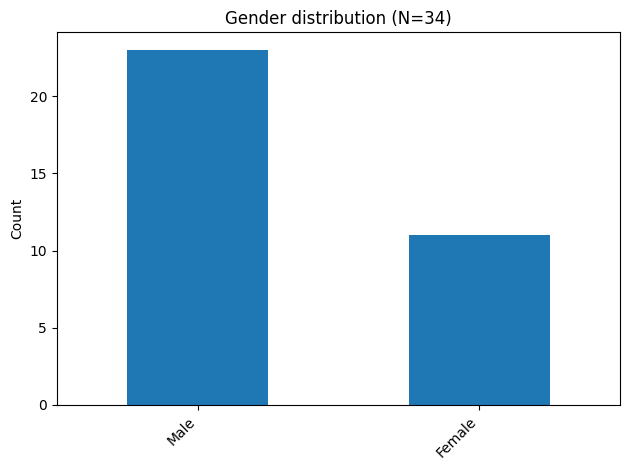


-- Race --
                                  Count  Percent
Race                                            
White                                10     29.4
Asian                                 9     26.5
Black or African American             8     23.5
Hispanic or Latino (of any race)      4     11.8
Two or more races                     2      5.9
Middle East                           1      2.9


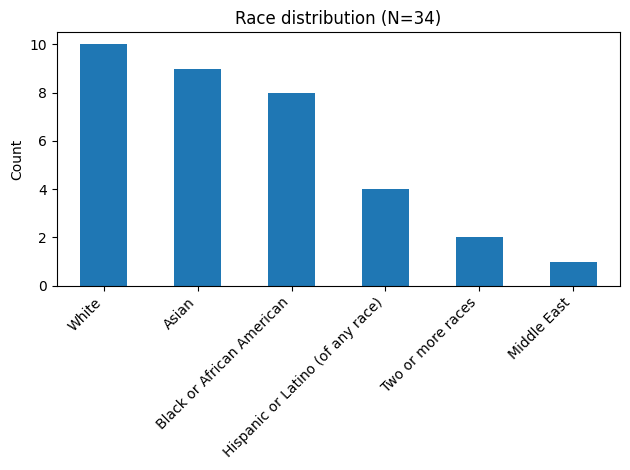

In [ ]:
# Demographics summary + tables + plots
# File: Demographics.xlsx (uploaded)
# Edit the COLUMN NAMES in the config section to match your sheet.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Demographics.xlsx"

# ----------------------------
# CONFIG: change these to match your file
# ----------------------------
SHEET_NAME = 0  # or "Sheet1"
ID_COL = None   # e.g., "ParticipantID" (optional)

# Example common demographic columns (edit as needed)
NUMERIC_COLS = ["Age"]  # e.g., ["Age"]
CATEGORICAL_COLS = [
    "Gender",           # e.g., "Gender"
    "Race",             # e.g., "Race/Ethnicity"
]

# If you have multiple-select columns like "Race" with "A;B;C"
MULTI_SELECT_COLS = []  # e.g., ["Race"]

# ----------------------------
# LOAD
# ----------------------------
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Basic cleaning: trim whitespace, unify blanks
df = df.copy()
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.strip()
        df.loc[df[c].isin(["", "nan", "None", "NA", "N/A"]), c] = np.nan

if ID_COL and ID_COL in df.columns:
    # drop duplicate IDs, keeping first (optional)
    df = df.drop_duplicates(subset=[ID_COL], keep="first")

N = len(df)
print(f"Rows (participants): {N}")

# ----------------------------
# HELPERS
# ----------------------------
def freq_table(series: pd.Series, dropna=True) -> pd.DataFrame:
    """Counts + percentages for a categorical column."""
    s = series.dropna() if dropna else series
    counts = s.value_counts(dropna=not dropna)
    perc = (counts / counts.sum()) * 100
    out = pd.DataFrame({"Count": counts, "Percent": perc.round(1)})
    out.index.name = series.name
    return out

def numeric_summary(series: pd.Series) -> pd.DataFrame:
    """Descriptives for numeric column."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    out = {
        "N": len(s),
        "Mean": s.mean(),
        "SD": s.std(ddof=1) if len(s) > 1 else np.nan,
        "Median": s.median(),
        "Min": s.min(),
        "Max": s.max(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
    }
    return pd.DataFrame(out, index=[series.name]).round(3)

def plot_bar_from_table(tab: pd.DataFrame, title: str):
    """Simple bar chart from a freq table (Count)."""
    ax = tab["Count"].plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def expand_multiselect(series: pd.Series, sep=";") -> pd.Series:
    """
    Turn multi-select cell strings like "A; B; C" into one long Series of options.
    """
    s = series.dropna().astype(str)
    parts = s.str.split(sep)
    exploded = parts.explode().str.strip()
    exploded = exploded.replace("", np.nan).dropna()
    exploded.name = series.name
    return exploded



# ----------------------------
# CATEGORICAL DEMOGRAPHICS
# ----------------------------
print("\n=== Categorical demographics ===")
all_tables = {}
for col in CATEGORICAL_COLS:
    if col not in df.columns:
        print(f"[Missing column] {col}")
        continue

    if col in MULTI_SELECT_COLS:
        expanded = expand_multiselect(df[col], sep=";")
        tab = freq_table(expanded)
        all_tables[col] = tab
        print(f"\n-- {col} (multi-select expanded) --")
        print(tab.to_string())
        plot_bar_from_table(tab, f"{col} distribution (N options={tab['Count'].sum()})")
    else:
        tab = freq_table(df[col])
        all_tables[col] = tab
        print(f"\n-- {col} --")
        print(tab.to_string())
        plot_bar_from_table(tab, f"{col} distribution (N={tab['Count'].sum()})")



# Code Frequency

Code Frequency

In [ ]:
import pandas as pd

# Load files
parsons = pd.read_excel("Parsons Problem Adv Disadv Tag frequency.xlsx")
traditional = pd.read_excel("Traditional Programming Adv Disadv tag frequency.xlsx")

def get_tag_frequency(df):
    # keep only tag columns
    tags_df = df.iloc[:, 1:]

    # flatten all tag columns into one series
    tags = tags_df.stack().dropna().astype(str)

    # clean spaces
    tags = tags.str.strip()
    tags = tags.str.replace(r"\s+", " ", regex=True)

    # count frequency
    freq = tags.value_counts().reset_index()
    freq.columns = ["Tag", "Frequency"]

    return freq

# Get frequencies
parsons_freq = get_tag_frequency(parsons)
traditional_freq = get_tag_frequency(traditional)

print("Parsons Problem Tag Frequency")
print(parsons_freq)

print("\nTraditional Programming Tag Frequency")
print(traditional_freq)


Parsons Problem Tag Frequency
                                  Tag  Frequency
0                         Ease of use         28
1              Ineffective Experience         12
2                          Efficiency         10
3            Interaction Difficulties          9
4             Reduced Problem Solving          9
5   Limited or Surface-level Learning          7
6                     Positive Affect          4
7           Lack of Coding Experience          3
8                    Limited Features          2
9                      Low Engagement          2
10                 Effective Learning          1
11         Device and Keyboard Issues          1
12                     Time Consuming          1
13                  Interface Support          1
14                Cognitive Challenge          1

Traditional Programming Tag Frequency
                           Tag  Frequency
0               Time Consuming         19
1            Typing Difficulty         19
2           Effective

Exercise Preference Tag and Type frequency

In [ ]:
import pandas as pd

# Load file
df = pd.read_excel("Exercise Preference - Tag Frequency.xlsx")

# Column names
participant_col = df.columns[0]
preference_col = df.columns[1]
tag_cols = df.columns[2:]

# -----------------------------------
# 1. Preferred Exercise Type Frequency
# -----------------------------------
pref_freq = df[preference_col].value_counts()

print("Preferred Exercise Type Frequency")
print(pref_freq)


# -----------------------------------
# 2. Tag Frequency
# -----------------------------------

# combine all tag columns
tags = df[tag_cols].stack().dropna()

# clean spaces
tags = tags.astype(str).str.strip()
tags = tags.str.replace(r"\s+", " ", regex=True)

tag_freq = tags.value_counts()

print("\nTag Frequency")
print(tag_freq)


Preferred Exercise Type Frequency
Prefererred Types
Drag and Drop              24
Traditional Programming     7
Both                        3
Name: count, dtype: int64

Tag Frequency
Ease of use                          17
Efficiency                            9
Real Coding Experience                5
Interface Support                     4
Effective Learning                    4
Positive Affect                       3
Reduced Physical Discomfort           3
Limited or Surface-level Learning     2
Low Effort                            1
Ineffective Experience                1
Cognitive Challenge                   1
Name: count, dtype: int64


Tag Frequency for Each  types

In [ ]:
import pandas as pd

# Load file
df = pd.read_excel("Exercise Preference - Tag Frequency.xlsx")

# Columns
preference_col = df.columns[1]   # preferred exercise type
tag_cols = df.columns[2:]        # tag columns

# Convert tag columns to long format
tags = df.melt(
    id_vars=[preference_col],
    value_vars=tag_cols,
    value_name="Tag"
)

# Remove empty tags
tags = tags.dropna(subset=["Tag"])

# Clean spaces
tags["Tag"] = tags["Tag"].astype(str).str.strip()
tags["Tag"] = tags["Tag"].str.replace(r"\s+", " ", regex=True)

# Count tags by preferred exercise
result = (
    tags.groupby([preference_col, "Tag"])
    .size()
    .reset_index(name="Frequency")
)

# Sort results
result = result.sort_values([preference_col, "Frequency"], ascending=[True, False])

print(result)

for pref in result[preference_col].unique():
    print("\n", pref)
    subset = result[result[preference_col] == pref]
    for _, row in subset.iterrows():
        print(f"   {row['Tag']} - {row['Frequency']}")

          Prefererred Types                                Tag  Frequency
0                      Both                Cognitive Challenge          1
1                      Both                        Ease of use          1
2                      Both                 Effective Learning          1
3                      Both  Limited or Surface-level Learning          1
4                      Both             Real Coding Experience          1
5             Drag and Drop                        Ease of use         16
6             Drag and Drop                         Efficiency          9
8             Drag and Drop                  Interface Support          3
11            Drag and Drop                    Positive Affect          3
12            Drag and Drop        Reduced Physical Discomfort          3
7             Drag and Drop             Ineffective Experience          1
9             Drag and Drop  Limited or Surface-level Learning          1
10            Drag and Drop           